# Multi-Frame Gestalt Experiment with Frame-by-Frame Gibbs Sampling

This notebook runs tracking analysis with re-initialization at each frame:
1. Load and visualize depth/flow data
2. Compute 3D points and motion
3. Extract gestalt segmentation
4. Initialize with hierarchical k-means
5. Run full Gibbs sampling on first frame
6. Analyze and visualize results
7. Run frame-by-frame tracking with fresh Gibbs initialization (10 frames)
8. Save and visualize tracked segmentation masks

## Imports and Setup

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter, sobel
import matplotlib.cm as cm


# Set random seeds for reproducibility
RANDOM_SEED = 42

import random

# Seed all random number generators
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"Random seed set to {RANDOM_SEED} for reproducibility")
sys.path.append('/home/esli/GenMatter')

from gestalt_experiment_algorithm import *

Random seed set to 42 for reproducibility


## Configuration

In [2]:
explore_scene = 'scene_00001'
explore_texture = 'texture_00'
custom_hyperparams = {
    "number_of_blobs": 100,
    "number_of_hyperblobs": 5,
    "num_seeded_runs": 1,
}

number_of_blobs = custom_hyperparams["number_of_blobs"]
number_of_hyperblobs = custom_hyperparams["number_of_hyperblobs"]

print(f"Scene: {explore_scene}")
print(f"Texture: {explore_texture}")
print(f"Number of blobs: {number_of_blobs}")
print(f"Number of hyperblobs: {number_of_hyperblobs}")

Scene: scene_00001
Texture: texture_00
Number of blobs: 100
Number of hyperblobs: 5


In [3]:
def load_six_frame_gestalt_data(scene, texture):
    """Load depth and flow data for first 6 frames only"""
    # Load depth data from six-frame file
    depth_file = os.path.join('/home/esli/GenMatter/assets/from_thomas', 
                               scene, texture, 'output_six_frame_depths.npz')
    if not os.path.exists(depth_file):
        raise FileNotFoundError(f"Depth file not found: {depth_file}")
    
    depth_data = np.load(depth_file)
    if 'depths' in depth_data:
        inv_rel_depth = depth_data['depths']
    else:
        inv_rel_depth = next(iter(depth_data.values()))
    
    # Process depth data (matching load_gestalt_data processing)
    clipped_inverse_depth = np.clip(inv_rel_depth, 5, 1500)
    epsilon = 1e-6
    depth = 3000.0 / (clipped_inverse_depth + epsilon)
    depth = np.clip(depth, 0.25, 20.0)
    
    # Only use first 6 frames of depth
    depth = depth[:6]
    
    # Load flow data
    flow_file = os.path.join('/home/esli/GenMatter/raft_flows',
                             f'raft_flows_{scene}_{texture}.npz')
    if not os.path.exists(flow_file):
        raise FileNotFoundError(f"Flow file not found: {flow_file}")
    
    flow_data = np.load(flow_file)
    if 'flow' in flow_data:
        flow = flow_data['flow']
    else:
        flow = next(iter(flow_data.values()))
    
    # Only use first 5 frames of flow (for 6 depth frames)
    flow = flow[:5]
    
    return depth, flow


## STEP 1: Load Raw Data

Depth shape: (6, 1000, 1000)
Flow shape: (5, 520, 960, 2)


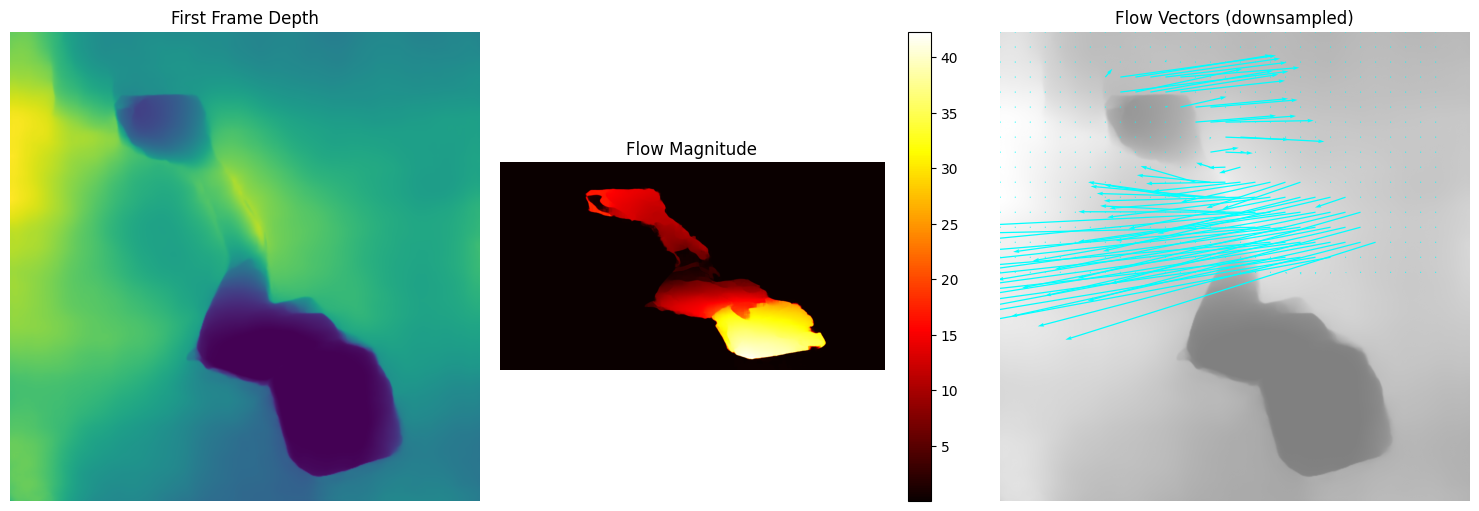

In [4]:
depth, flow = load_six_frame_gestalt_data(explore_scene, explore_texture)

print(f"Depth shape: {depth.shape}")  # [6, H, W]
print(f"Flow shape: {flow.shape}")    # [5, H, W, 2]

# Visualize first frame
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Depth map
axes[0].imshow(depth[0], cmap='viridis')
axes[0].set_title('First Frame Depth')
axes[0].axis('off')

# Flow magnitude
flow_mag = np.sqrt(flow[0, :, :, 0]**2 + flow[0, :, :, 1]**2)
im1 = axes[1].imshow(flow_mag, cmap='hot')
axes[1].set_title('Flow Magnitude')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1])

# Flow vectors (downsampled for visibility)
step = 32
y, x = np.mgrid[0:flow.shape[1]:step, 0:flow.shape[2]:step]
u = flow[0, ::step, ::step, 0]
v = flow[0, ::step, ::step, 1]
axes[2].imshow(depth[0], cmap='gray', alpha=0.5)
axes[2].quiver(x, y, u, -v, color='cyan', scale=50)
axes[2].set_title('Flow Vectors (downsampled)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [5]:
# Data is now loaded from `output_six_frame_depths.npz` with first 6 frames only (5 flow frames)

## STEP 2: Compute 3D Points and Motion

Downsampling from 1000 to 96 (factor: 8)


Valid motion vectors: 12001/46080 (26.04%) with magnitude >= 0.05
Points 3D shape: (5, 9216, 3)
Motion 3D shape: (5, 9216, 3)
Valid motion mask shape: (5, 9216)


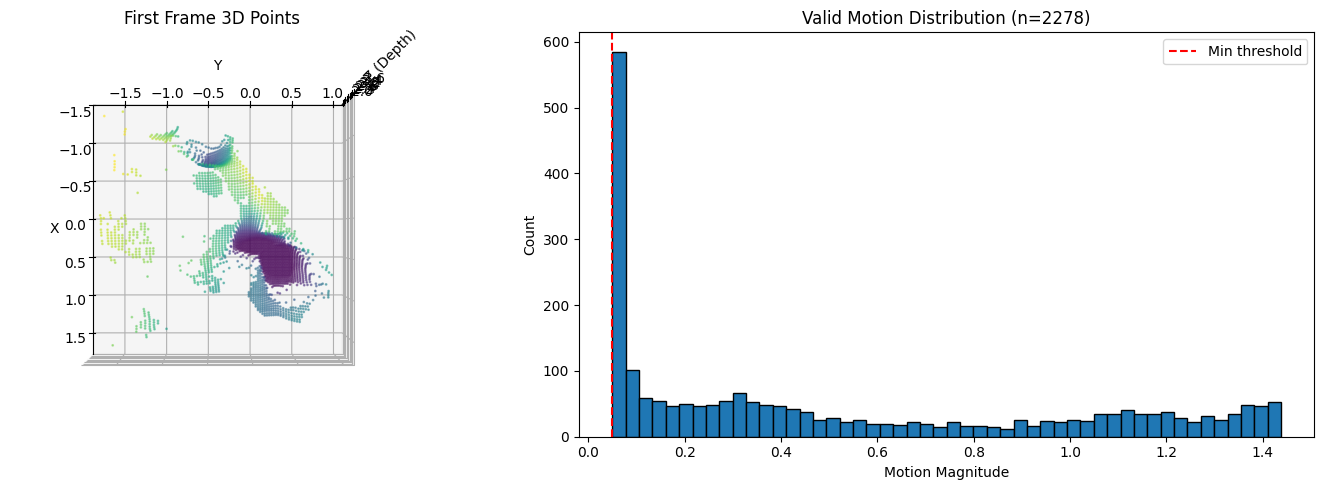

In [6]:
points_3d, motion_3d, motion_valid_mask = compute_3d_points_and_motion(
    depth, flow, downsample_factor=8, min_motion_magnitude=0.05
)

print(f"Points 3D shape: {points_3d.shape}")  # [N_frames, N_points, 3]
print(f"Motion 3D shape: {motion_3d.shape}")  # [N_frames, N_points, 3]
print(f"Valid motion mask shape: {motion_valid_mask.shape}")

# Get first frame data for visualization
tracked_points_frame0 = points_3d[0]  # [N_points, 3]
tracked_motion_vectors_frame0 = motion_3d[0]  # [N_points, 3]

# Visualize
fig = plt.figure(figsize=(15, 5))

# 3D scatter plot
ax1 = fig.add_subplot(121, projection='3d')
valid_points = tracked_points_frame0[motion_valid_mask[0]]
# Transpose XY for visualization only
valid_points_vis = valid_points[:, [1, 0, 2]]
ax1.scatter(valid_points_vis[:, 0], valid_points_vis[:, 1], valid_points_vis[:, 2], 
           c=valid_points[:, 2], cmap='viridis', s=1, alpha=0.5)
ax1.set_title('First Frame 3D Points')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z (Depth)')
ax1.view_init(elev=90, azim=0)

# Motion magnitude histogram
ax2 = fig.add_subplot(122)
motion_mag = np.linalg.norm(motion_3d[0], axis=1)
valid_motion_mag = motion_mag[motion_valid_mask[0]]
ax2.hist(valid_motion_mag, bins=50, edgecolor='black')
ax2.set_xlabel('Motion Magnitude')
ax2.set_ylabel('Count')
ax2.set_title(f'Valid Motion Distribution (n={np.sum(motion_valid_mask[0])})')
ax2.axvline(0.05, color='red', linestyle='--', label='Min threshold')
ax2.legend()

plt.tight_layout()
plt.show()

## STEP 3: Extract Gestalt Segmentation

Target resolution: 96x96
Loading true segmentation masks from PNG files (first 5 frames)...
  Loading frame 0...
  Loading frame 1...
  Loading frame 2...
  Loading frame 3...
  Loading frame 4...
Loaded 5 true masks
Frame 0 true mask: 1442 ROI points
Frame 0 combined mask: 1410 ROI points


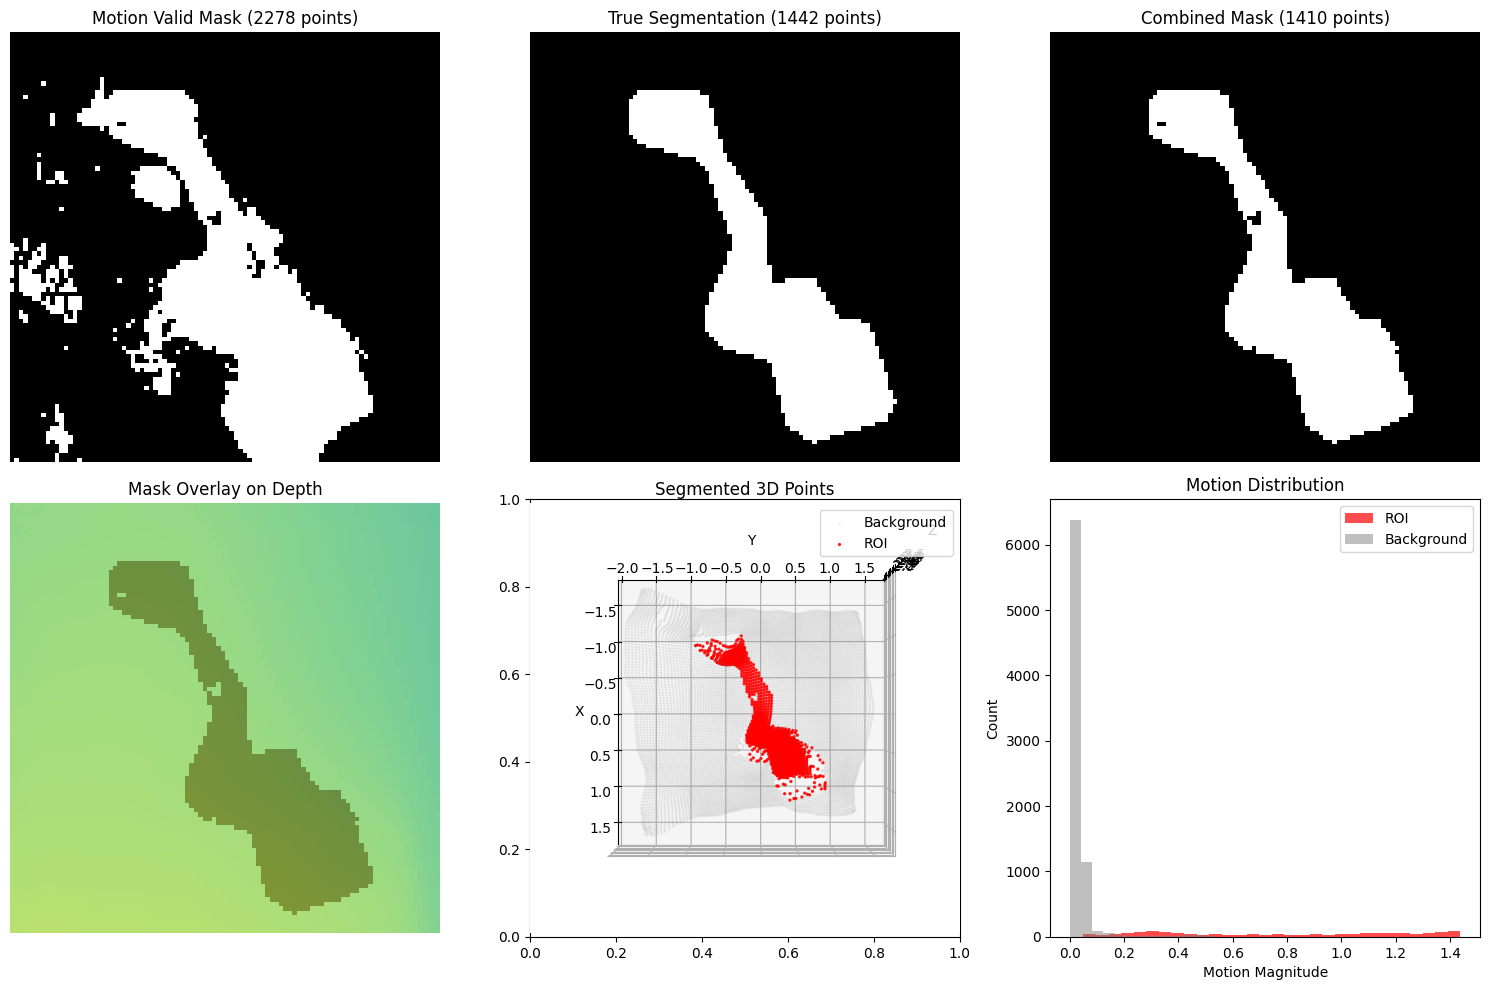

In [7]:
# Compute target size (matching compute_3d_points_and_motion downsampling)
orig_H, orig_W = depth.shape[1:3]
target_hw = max(orig_H, orig_W) // 8  # Match downsample_factor=8
target_hw = (target_hw // 32) * 32  # Round to nearest multiple of 32
if target_hw < 32:
    target_hw = 32

print(f"Target resolution: {target_hw}x{target_hw}")

# Resize to square
depth_sq = resize_to_square(depth, target_hw)
flow_sq = resize_to_square(flow, target_hw)

# Load true segmentation masks from PNG files
import cv2
import os

mask_dir = "/home/esli/GenMatter/assets/from_thomas/scene_00001/render_passes/masks"

def load_true_mask(frame_idx, target_size=(96, 96)):
    """Load and process true segmentation mask from PNG file."""
    mask_path = os.path.join(mask_dir, f"Image{frame_idx+1:04d}.png")
    
    if not os.path.exists(mask_path):
        raise FileNotFoundError(f"Mask file not found: {mask_path}")
    
    # Load mask (grayscale)
    mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # Resize to target size
    mask_resized = cv2.resize(mask_img, target_size, interpolation=cv2.INTER_NEAREST)
    
    # Binarize: assume object is non-zero, background is zero
    # Create boolean mask where True = object (foreground)
    binary_mask = mask_resized > 0
    
    # Flatten to 1D
    flat_mask = binary_mask.flatten()
    
    return flat_mask

# Load masks for first 6 frames only (matching depth frames)
num_frames = min(len(depth_sq), len(points_3d), 6)  # Limit to 6 frames
all_frame_segmentation_masks = []

print(f"Loading true segmentation masks from PNG files (first {num_frames} frames)...")
for frame_idx in range(num_frames):
    print(f"  Loading frame {frame_idx}...")
    
    true_mask = load_true_mask(frame_idx, target_size=(target_hw, target_hw))
    all_frame_segmentation_masks.append(true_mask)

all_frame_segmentation_masks = np.array(all_frame_segmentation_masks)
print(f"Loaded {len(all_frame_segmentation_masks)} true masks")

# Create combined masks (true mask & motion valid)
all_frame_combined_masks = []
for frame_idx in range(num_frames):
    combined = all_frame_segmentation_masks[frame_idx] & motion_valid_mask[frame_idx]
    all_frame_combined_masks.append(combined)

all_frame_combined_masks = np.array(all_frame_combined_masks)

# For backwards compatibility
first_frame_seg = all_frame_segmentation_masks[0]
combined_mask = all_frame_combined_masks[0]

print(f"Frame 0 true mask: {np.sum(first_frame_seg)} ROI points")
print(f"Frame 0 combined mask: {np.sum(combined_mask)} ROI points")

# Visualize masks
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Motion mask
axes[0, 0].imshow(motion_valid_mask[0].reshape((target_hw, target_hw)), cmap='gray')
axes[0, 0].set_title(f'Motion Valid Mask ({np.sum(motion_valid_mask[0])} points)')
axes[0, 0].axis('off')

# True segmentation
axes[0, 1].imshow(first_frame_seg.reshape((target_hw, target_hw)), cmap='gray')
axes[0, 1].set_title(f'True Segmentation ({np.sum(first_frame_seg)} points)')
axes[0, 1].axis('off')

# Combined mask
axes[0, 2].imshow(combined_mask.reshape((target_hw, target_hw)), cmap='gray')
axes[0, 2].set_title(f'Combined Mask ({np.sum(combined_mask)} points)')
axes[0, 2].axis('off')

# Overlay on depth
axes[1, 0].imshow(depth[0], cmap='viridis')
axes[1, 0].imshow(combined_mask.reshape((target_hw, target_hw)), cmap='Reds', alpha=0.3)
axes[1, 0].set_title('Mask Overlay on Depth')
axes[1, 0].axis('off')

# 3D visualization
ax_3d = fig.add_subplot(2, 3, 5, projection='3d')
roi_points = tracked_points_frame0[combined_mask]
bg_points = tracked_points_frame0[~combined_mask]
# Transpose XY for visualization only
roi_points_vis = roi_points[:, [1, 0, 2]]
bg_points_vis = bg_points[:, [1, 0, 2]]
ax_3d.scatter(bg_points_vis[:, 0], bg_points_vis[:, 1], bg_points_vis[:, 2], 
             c='gray', s=1, alpha=0.1, label='Background')
ax_3d.scatter(roi_points_vis[:, 0], roi_points_vis[:, 1], roi_points_vis[:, 2], 
             c='red', s=2, alpha=0.8, label='ROI')
ax_3d.set_title('Segmented 3D Points')
ax_3d.set_xlabel('X')
ax_3d.set_ylabel('Y')
ax_3d.set_zlabel('Z')
ax_3d.legend()
ax_3d.view_init(elev=90, azim=0)

# Motion magnitude of ROI
motion_mag = np.linalg.norm(tracked_motion_vectors_frame0, axis=1)
axes[1, 2].hist(motion_mag[combined_mask], bins=30, alpha=0.7, label='ROI', color='red')
axes[1, 2].hist(motion_mag[~combined_mask], bins=30, alpha=0.5, label='Background', color='gray')
axes[1, 2].set_xlabel('Motion Magnitude')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Motion Distribution')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

## STEP 4: Hierarchical K-Means Clustering

K-means CHM created
ROI blobs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
ROI hyperblobs: [0]


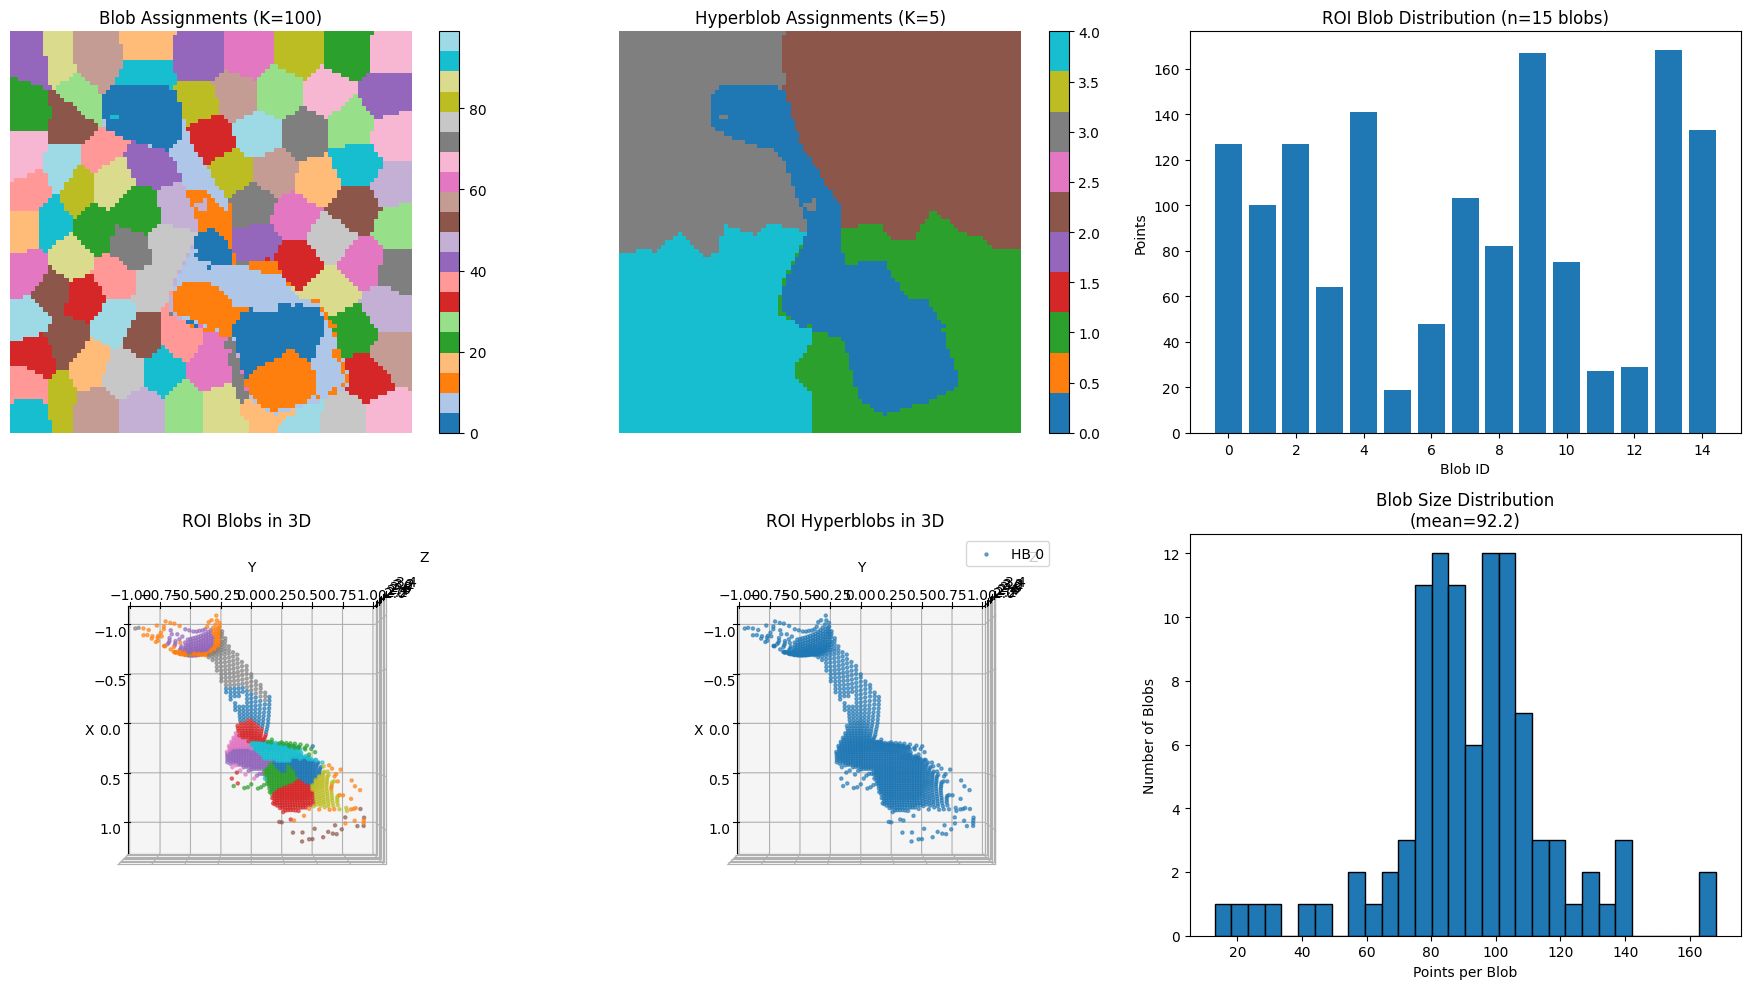

In [8]:
# Initialize with hierarchical k-means
# Note: Pass full 3D arrays, function will extract frame_idx=0 internally
kmeans_chm, roi_blob_indices, roi_hyperblob_indices = make_hierarchical_kmeans_chm_with_mask_fixed_hyperblob(
    points_3d, number_of_blobs, number_of_hyperblobs,
    segmentation_mask=combined_mask, motion_vectors=motion_3d, frame_idx=0
)

print(f"K-means CHM created")
print(f"ROI blobs: {roi_blob_indices}")
print(f"ROI hyperblobs: {roi_hyperblob_indices}")

# Get assignments from choice map
blob_assignments = np.array(kmeans_chm['datapoints', 'blob_assignments'])
hyperblob_assignments = np.array(kmeans_chm['blobs', 'hyperblob_assignments'])

# Visualize clustering
fig = plt.figure(figsize=(18, 10))

# Blob-level clustering (2D)
ax1 = fig.add_subplot(2, 3, 1)
blob_img = blob_assignments.reshape((target_hw, target_hw))
im1 = ax1.imshow(blob_img, cmap='tab20')
ax1.set_title(f'Blob Assignments (K={number_of_blobs})')
ax1.axis('off')
plt.colorbar(im1, ax=ax1)

# Hyperblob-level clustering (via blob mapping)
ax2 = fig.add_subplot(2, 3, 2)
pixel_hyperblobs = np.zeros_like(blob_assignments)
for i in range(len(blob_assignments)):
    blob_id = blob_assignments[i]
    if blob_id < number_of_blobs:
        pixel_hyperblobs[i] = hyperblob_assignments[blob_id]
    else:
        pixel_hyperblobs[i] = -1
im2 = ax2.imshow(pixel_hyperblobs.reshape((target_hw, target_hw)), cmap='tab10')
ax2.set_title(f'Hyperblob Assignments (K={number_of_hyperblobs})')
ax2.axis('off')
plt.colorbar(im2, ax=ax2)

# ROI blobs histogram
ax3 = fig.add_subplot(2, 3, 3)
roi_blob_assignments = blob_assignments[combined_mask]
unique_blobs, counts = np.unique(roi_blob_assignments[roi_blob_assignments < number_of_blobs], 
                                  return_counts=True)
ax3.bar(unique_blobs, counts)
ax3.set_xlabel('Blob ID')
ax3.set_ylabel('Points')
ax3.set_title(f'ROI Blob Distribution (n={len(unique_blobs)} blobs)')

# 3D visualization of blobs
ax4 = fig.add_subplot(2, 3, 4, projection='3d')
roi_mask = combined_mask
for blob_id in roi_blob_indices:
    mask = (blob_assignments == blob_id) & roi_mask
    if np.sum(mask) > 0:
        pts = tracked_points_frame0[mask]
        pts_vis = pts[:, [1, 0, 2]]  # Transpose for visualization
        ax4.scatter(pts_vis[:, 0], pts_vis[:, 1], pts_vis[:, 2], s=5, alpha=0.6)
ax4.set_title('ROI Blobs in 3D')
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
ax4.view_init(elev=90, azim=0)

# 3D visualization of hyperblobs
ax5 = fig.add_subplot(2, 3, 5, projection='3d')
for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(hyperblob_assignments == hb_id)[0]
    mask = np.isin(blob_assignments, hb_blobs) & roi_mask
    if np.sum(mask) > 0:
        pts = tracked_points_frame0[mask]
        pts_vis = pts[:, [1, 0, 2]]  # Transpose for visualization
        ax5.scatter(pts_vis[:, 0], pts_vis[:, 1], pts_vis[:, 2], s=5, alpha=0.6, label=f'HB {hb_id}')
ax5.set_title('ROI Hyperblobs in 3D')
ax5.set_xlabel('X')
ax5.set_ylabel('Y')
ax5.set_zlabel('Z')
ax5.legend()
ax5.view_init(elev=90, azim=0)

# Blob size distribution
ax6 = fig.add_subplot(2, 3, 6)
all_blob_sizes = [np.sum(blob_assignments == i) for i in range(number_of_blobs)]
ax6.hist(all_blob_sizes, bins=30, edgecolor='black')
ax6.set_xlabel('Points per Blob')
ax6.set_ylabel('Number of Blobs')
ax6.set_title(f'Blob Size Distribution\n(mean={np.mean(all_blob_sizes):.1f})')

plt.tight_layout()
plt.show()

## STEP 5: Initialize HDGMM Hyperparameters

In [9]:
# Extract empirical statistics from k-means clustering
blob_means = np.array([tracked_points_frame0[blob_assignments == i].mean(axis=0) 
                       for i in range(number_of_blobs)])

# Debug: Check hyperblob assignments
print("\nDEBUG: Hyperblob assignment distribution:")
for i in range(number_of_hyperblobs):
    n_blobs = np.sum(hyperblob_assignments == i)
    print(f"  Hyperblob {i}: {n_blobs} blobs")

# Compute hyperblob means, handling empty clusters
hyperblob_means_list = []
for i in range(number_of_hyperblobs):
    hb_blob_means = blob_means[hyperblob_assignments == i]
    if len(hb_blob_means) > 0:
        hyperblob_means_list.append(hb_blob_means.mean(axis=0))
    else:
        # Use overall blob mean for empty hyperblob
        print(f"  WARNING: Hyperblob {i} has no blobs! Using overall blob mean.")
        hyperblob_means_list.append(blob_means.mean(axis=0))

hyperblob_means = np.array(hyperblob_means_list)

empirical_mu_H = hyperblob_means.mean(axis=0)
empirical_sigma_H = np.std(hyperblob_means, axis=0).mean()

print(f"\nDEBUG: After computation:")
print(f"  hyperblob_means shape: {hyperblob_means.shape}")
print(f"  empirical_mu_H: {empirical_mu_H}")
print(f"  empirical_sigma_H: {empirical_sigma_H}")

# Compute empirical covariances
blob_points = [tracked_points_frame0[blob_assignments == i] for i in range(number_of_blobs)]
blob_covs = [np.cov(pts.T) if len(pts) > 3 else np.eye(3) * 0.01 for pts in blob_points]
empirical_Psi_B = np.mean(blob_covs, axis=0)

hyperblob_blob_means = [blob_means[hyperblob_assignments == i] for i in range(number_of_hyperblobs)]
hyperblob_covs = [np.cov(means.T) if len(means) > 3 else np.eye(3) * 0.1 
                  for means in hyperblob_blob_means]
empirical_Psi_H = np.mean(hyperblob_covs, axis=0)

# Velocity covariances
blob_velocities = [tracked_motion_vectors_frame0[blob_assignments == i] for i in range(number_of_blobs)]
blob_vel_covs = [np.cov(vels.T) if len(vels) > 3 else np.eye(3) * 0.01 for vels in blob_velocities]
empirical_Psi_V = np.mean(blob_vel_covs, axis=0)

# Concentration parameters (degrees of freedom)
empirical_nu_H = 5.0
empirical_nu_B = 5.0
empirical_nu_V = 5.0

# Helper functions for parameter types
f_ = lambda x: jnp.float32(x)
snp = lambda x: StaticJnp(jnp.array(x))

# Get dimensions from k-means results
num_datapoints = kmeans_chm['datapoints', 'datapoint_positions'].shape[0]
num_blobs = number_of_blobs
num_hyperblobs = number_of_hyperblobs

# Create hyperparameters with all required fields
  # IMPORTANT: Rotation and translation hyperparameters for tracking
hypers = HDGMM_Hyperparams.create(
    outlier_prob=f_(0.001),
    outlier_velocity_gamma_shape=f_(7.5),
    outlier_velocity_gamma_rate=f_(0.5),
    alpha=f_(1.0),
    beta=f_(1.0),
    mu_H=empirical_mu_H,
    sigma_H=empirical_sigma_H,
    nu_H=empirical_nu_H,
    Psi_H=empirical_Psi_H,
    nu_B=empirical_nu_B,
    Psi_B=empirical_Psi_B,
    sigma_V=f_(10e14),
    nu_V=empirical_nu_V,
    Psi_V=empirical_Psi_V,
    translation_gaussian_scale=snp(f_(0.2)),
    translation_max_radius=snp(0.35),
    translation_num_radii_cells=snp(15),
    translation_theta_step_deg=snp(15),
    # Rotation hyperparameters - very weak prior to allow diversity
    rotation_vmf_kappa=snp(f_(100)),      # Very weak prior (was 5.0, originally 100)
    rotation_angle_max_deg=snp(10),       # Larger max angle (was 25)
    rotation_angle_step_deg=snp(0.5),       # Finer grid (was 15)
    n_hyperblobs=num_hyperblobs,
    n_blobs=num_blobs,
    n_datapoints=num_datapoints
)

# Define Gibbs sampling configuration
# K-means provides initialization; tracking_gibbs uses soft priors for temporal coherence
GIBBS_DIALS = {
    "blob_weights": True,
    "hyperblob_weights": False,
    "blob_assignments": True,
    "hyperblob_assignments": True,
    "hyperblob_covs": False,
    "blob_covs": True,
    "blob_vel_covs": True,
    "blob_vel_means": True,
    "hyperblob_means": False,  # Keep hyperblob structure fixed
    "blob_means": True,  # Allow updates with soft prior
    'hyperblob_rot_vels': True,     # ENABLED - was False!
    'hyperblob_trans_vels': True    # ENABLED - was False!
}

print("Hyperparameters initialized:")
print(f"  n_datapoints: {num_datapoints}")
print(f"  n_blobs: {num_blobs}")
print(f"  n_hyperblobs: {num_hyperblobs}")
print(f"  mu_H: {empirical_mu_H}")
print(f"  sigma_H: {empirical_sigma_H:.4f}")
print(f"  nu_H: {empirical_nu_H}")
print(f"  nu_B: {empirical_nu_B}")
print(f"  nu_V: {empirical_nu_V}")
print(f"\nRotation hyperparameters (for tracking):")
print(f"  rotation_vmf_kappa: 0.5 (very weak prior)")
print(f"  rotation_angle_max_deg: 45")
print(f"  rotation_angle_step_deg: 5")
print(f"\nGibbs dials (first frame):")
for key, val in GIBBS_DIALS.items():
    print(f"  {key}: {val}")



DEBUG: Hyperblob assignment distribution:
  Hyperblob 0: 15 blobs
  Hyperblob 1: 18 blobs
  Hyperblob 2: 24 blobs
  Hyperblob 3: 20 blobs
  Hyperblob 4: 23 blobs

DEBUG: After computation:
  hyperblob_means shape: (5, 3)
  empirical_mu_H: [-0.07853019  0.04435326  2.8555362 ]
  empirical_sigma_H: 0.5490772724151611


Hyperparameters initialized:
  n_datapoints: 9216
  n_blobs: 100
  n_hyperblobs: 5
  mu_H: [-0.07853019  0.04435326  2.8555362 ]
  sigma_H: 0.5491
  nu_H: 5.0
  nu_B: 5.0
  nu_V: 5.0

Rotation hyperparameters (for tracking):
  rotation_vmf_kappa: 0.5 (very weak prior)
  rotation_angle_max_deg: 45
  rotation_angle_step_deg: 5

Gibbs dials (first frame):
  blob_weights: True
  hyperblob_weights: False
  blob_assignments: True
  hyperblob_assignments: True
  hyperblob_covs: False
  blob_covs: True
  blob_vel_covs: True
  blob_vel_means: True
  hyperblob_means: False
  blob_means: True
  hyperblob_rot_vels: True
  hyperblob_trans_vels: True


## STEP 6: Run Full Gibbs Sampling on First Frame

In [10]:
import jax
from jax.random import key as jkey

# Initialize random key
# Initialize JAX random key with fixed seed for reproducibility
key = jkey(RANDOM_SEED)
print(f"JAX key initialized with seed {RANDOM_SEED}")

# Initialize model with importance sampling
key, key_importance = jax.random.split(key)
init_tr, _ = model_jimportance(key_importance, kmeans_chm, (hypers,))
init_hdgmm_state = init_tr.get_retval()

print("Initial state created via importance sampling")

# Run Gibbs burn-in
num_gibbs_iterations = 101
num_inner_loops = 5

print(f"\nRunning {num_gibbs_iterations} Gibbs iterations...")
key, init_gibbs_key = jax.random.split(key)

gibbs_wtrs = hdgmm_full_gibbs(
    init_gibbs_key, 
    init_hdgmm_state, 
    num_gibbs_iterations, 
    GIBBS_DIALS, 
    use_weighted_blobs=True, 
    num_gibbs_inner_loops=num_inner_loops
)

print("Gibbs sampling complete!")

# Get final converged state
converged_state = gibbs_wtrs[-1].retval

JAX key initialized with seed 42
Initial state created via importance sampling

Running 101 Gibbs iterations...
Gibbs sampling complete!


## Convergence Diagnostics

Computing convergence diagnostics and log probabilities...


E1022 20:13:48.434829   17787 hlo_lexer.cc:443] Failed to parse int literal: 9473407607229978178777909
/var/tmp/ipykernel_17787/3134497736.py:138: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax6.legend()


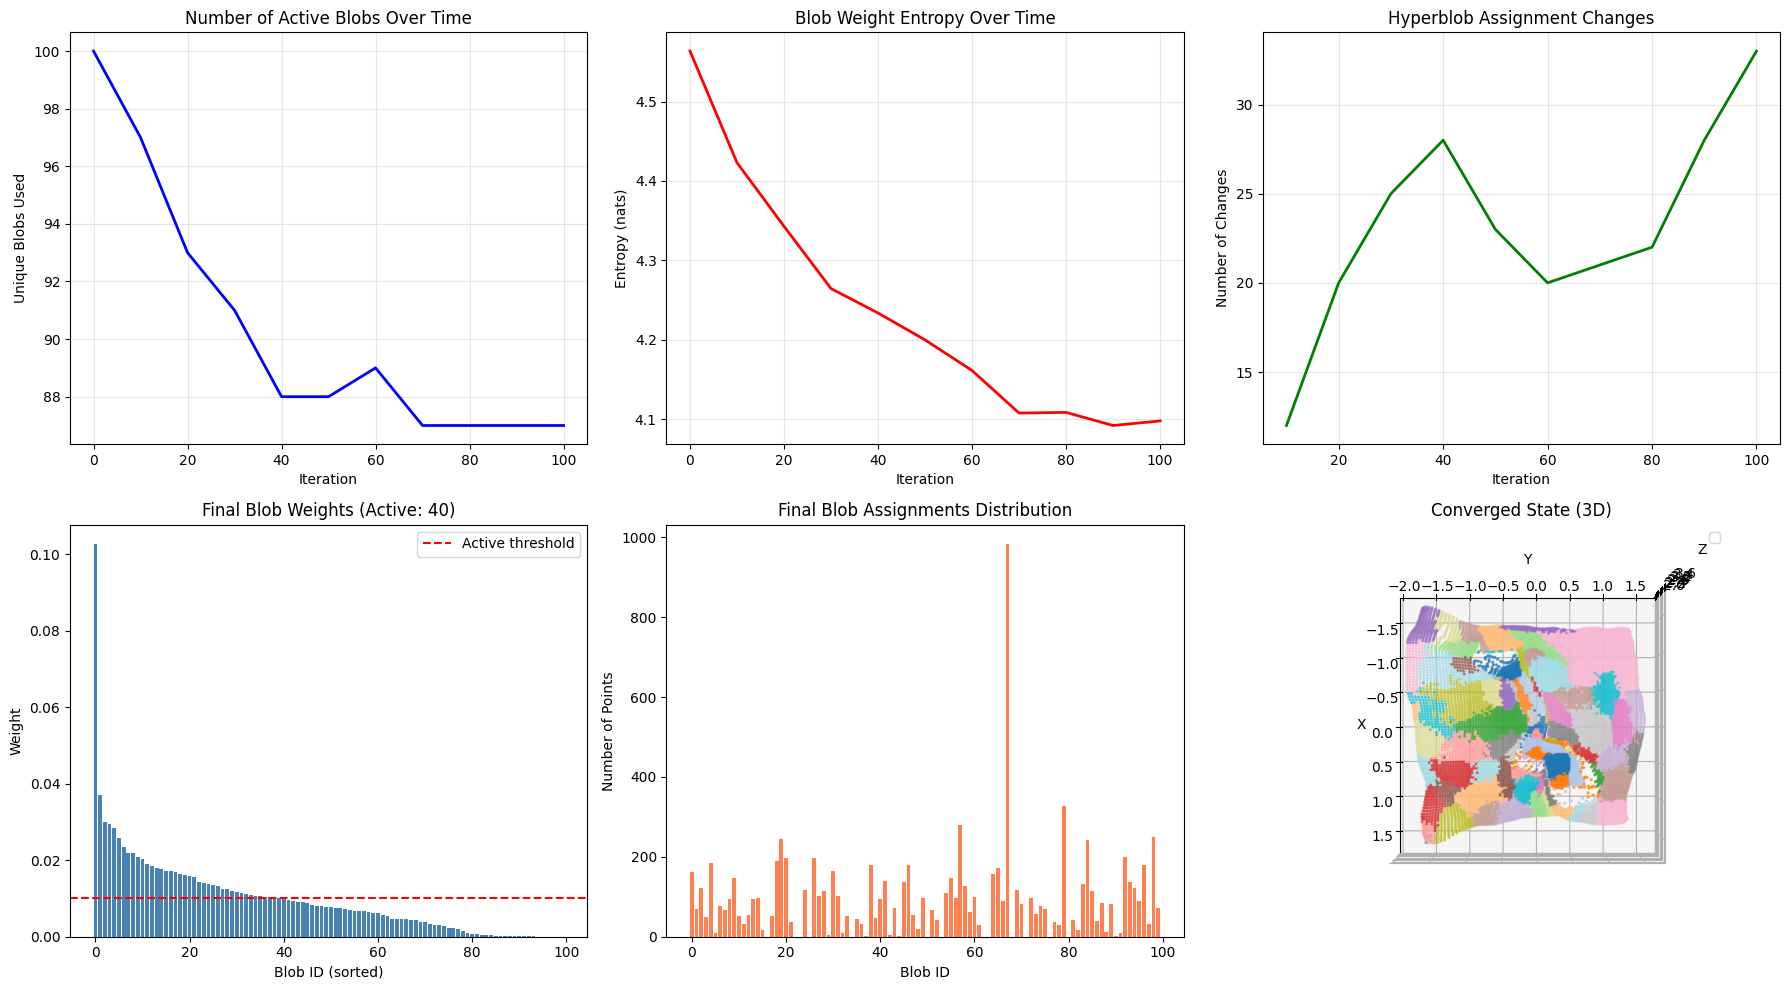


CONVERGENCE SUMMARY
Total iterations: 102
Final unique blobs: 87
Final blob weight entropy: 4.10 nats
Outlier points: 0 / 9216 (0.00%)
Mean points per active blob: 230.4

Log probabilities computed and saved for 11 samples
Max log prob: 107259.62 at iteration 80


In [11]:
# Extract statistics over iterations
n_blobs_history = []
blob_weight_entropy_history = []
hyperblob_assignment_changes = []
log_probs = []  # Store log probabilities

sample_freq = 10  # Sample every 10 iterations for efficiency

from gestalt_experiment_algorithm import HDGMM_model_3d
from genjax import ChoiceMapBuilder as C

print("Computing convergence diagnostics and log probabilities...")

for idx in range(0, len(gibbs_wtrs), sample_freq):
    state = gibbs_wtrs[idx].retval
    blob_assigns = np.array(state.datapoints_state.blob_assignments)
    blob_weights = np.array(state.blobs_state.blob_weights)
    hyperblob_assigns = np.array(state.blobs_state.hyperblob_assignments)
    
    # Track number of unique blobs used
    unique_blobs = len(np.unique(blob_assigns))
    n_blobs_history.append(unique_blobs)
    
    # Track blob weight entropy (higher = more uniform)
    weight_probs = blob_weights / blob_weights.sum()
    entropy = -np.sum(weight_probs * np.log(weight_probs + 1e-10))
    blob_weight_entropy_history.append(entropy)
    
    # Track hyperblob assignment changes
    if idx > 0:
        prev_hyperblob_assigns = np.array(gibbs_wtrs[idx - sample_freq].retval.blobs_state.hyperblob_assignments)
        n_changes = np.sum(hyperblob_assigns != prev_hyperblob_assigns)
        hyperblob_assignment_changes.append(n_changes)
    
    # Compute log probability for this sample
    chm = (
        C['hyperblobs', 'hyperblob_weights'].set(state.hyperblobs_state.hyperblob_weights) |
        C['hyperblobs', 'hyperblob_means'].set(state.hyperblobs_state.hyperblob_means) |
        C['hyperblobs', 'hyperblob_covs'].set(state.hyperblobs_state.hyperblob_covs) |
        C['hyperblobs', 'hyperblob_trans_vels'].set(state.hyperblobs_state.hyperblob_trans_vels) |
        C['hyperblobs', 'hyperblob_rot_vels'].set(state.hyperblobs_state.hyperblob_rot_vels) |
        
        C['blobs', 'hyperblob_assignments'].set(state.blobs_state.hyperblob_assignments) |
        C['blobs', 'blob_weights'].set(state.blobs_state.blob_weights) |
        C['blobs', 'blob_means'].set(state.blobs_state.blob_means) |
        C['blobs', 'blob_covs'].set(state.blobs_state.blob_covs) |
        C['blobs', 'blob_vel_means'].set(state.blobs_state.blob_vel_means) |
        C['blobs', 'blob_vel_covs'].set(state.blobs_state.blob_vel_covs) |
        
        C['datapoints', 'blob_assignments'].set(state.datapoints_state.blob_assignments) |
        C['datapoints', 'datapoint_positions'].set(state.datapoints_state.datapoint_positions) |
        C['datapoints', 'datapoint_vels'].set(state.datapoints_state.datapoint_vels)
    )
    
    weight, tr = HDGMM_model_3d.assess(chm, (state.hypers,))
    log_probs.append(float(weight))
    
    if (idx + 1) % 100 == 0:
        print(f"  Processed {idx+1}/{len(gibbs_wtrs)} samples")

log_probs = np.array(log_probs)

# Create convergence plots
iterations = np.arange(0, len(gibbs_wtrs), sample_freq)

fig = plt.figure(figsize=(18, 10))

# Plot 1: Number of active blobs
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(iterations, n_blobs_history, linewidth=2, color='blue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Unique Blobs Used')
ax1.set_title('Number of Active Blobs Over Time')
ax1.grid(True, alpha=0.3)

# Plot 2: Blob weight entropy
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(iterations, blob_weight_entropy_history, linewidth=2, color='red')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Entropy (nats)')
ax2.set_title('Blob Weight Entropy Over Time')
ax2.grid(True, alpha=0.3)

# Plot 3: Hyperblob assignment changes
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(iterations[1:], hyperblob_assignment_changes, linewidth=2, color='green')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Number of Changes')
ax3.set_title('Hyperblob Assignment Changes')
ax3.grid(True, alpha=0.3)

# Get final state for remaining plots
converged_state = gibbs_wtrs[-1].retval
final_blob_assignments = np.array(converged_state.datapoints_state.blob_assignments)
final_blob_weights = np.array(converged_state.blobs_state.blob_weights)

# Plot 4: Final blob weights
ax4 = fig.add_subplot(2, 3, 4)
sorted_weights = np.sort(final_blob_weights)[::-1]
ax4.bar(range(len(sorted_weights)), sorted_weights, color='steelblue')
ax4.set_xlabel('Blob ID (sorted)')
ax4.set_ylabel('Weight')
ax4.set_title(f'Final Blob Weights (Active: {np.sum(final_blob_weights > 0.01)})')
ax4.axhline(0.01, color='red', linestyle='--', label='Active threshold')
ax4.legend()

# Plot 5: Final blob assignments distribution
ax5 = fig.add_subplot(2, 3, 5)
unique_assignments, counts = np.unique(final_blob_assignments[final_blob_assignments < number_of_blobs], 
                                       return_counts=True)
ax5.bar(unique_assignments, counts, color='coral')
ax5.set_xlabel('Blob ID')
ax5.set_ylabel('Number of Points')
ax5.set_title(f'Final Blob Assignments Distribution')

# Plot 6: 3D visualization of converged state
ax6 = fig.add_subplot(2, 3, 6, projection='3d')
outlier_mask = final_blob_assignments >= number_of_blobs
inlier_mask = ~outlier_mask

if np.sum(outlier_mask) > 0:
    outlier_pts = tracked_points_frame0[outlier_mask]
    outlier_pts_vis = outlier_pts[:, [1, 0, 2]]  # Transpose for visualization
    ax6.scatter(outlier_pts_vis[:, 0], outlier_pts_vis[:, 1], outlier_pts_vis[:, 2], 
               c='red', s=5, alpha=0.5, label='Outliers')

if np.sum(inlier_mask) > 0:
    inlier_pts = tracked_points_frame0[inlier_mask]
    inlier_pts_vis = inlier_pts[:, [1, 0, 2]]  # Transpose for visualization
    assignments = final_blob_assignments[inlier_mask]
    ax6.scatter(inlier_pts_vis[:, 0], inlier_pts_vis[:, 1], inlier_pts_vis[:, 2], 
               c=assignments, cmap='tab20', s=2, alpha=0.6)

ax6.set_title('Converged State (3D)')
ax6.set_xlabel('X')
ax6.set_ylabel('Y')
ax6.set_zlabel('Z')
ax6.legend()
ax6.view_init(elev=90, azim=0)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("CONVERGENCE SUMMARY")
print("="*60)
print(f"Total iterations: {len(gibbs_wtrs)}")
print(f"Final unique blobs: {n_blobs_history[-1]}")
print(f"Final blob weight entropy: {blob_weight_entropy_history[-1]:.2f} nats")
print(f"Outlier points: {np.sum(outlier_mask)} / {len(outlier_mask)} ({100 * np.sum(outlier_mask) / len(outlier_mask):.2f}%)")
active_blobs = np.sum(final_blob_weights > 0.01)
if active_blobs > 0:
    print(f"Mean points per active blob: {np.sum(inlier_mask) / active_blobs:.1f}")
print(f"\nLog probabilities computed and saved for {len(log_probs)} samples")
print(f"Max log prob: {np.max(log_probs):.2f} at iteration {iterations[np.argmax(log_probs)]}")
print("="*60)

## Display Converged State

In [12]:
converged_state

HDGMM_State(
  hypers=HDGMM_Hyperparams(outlier_prob=<jax.Array(0.001, dtype=float32)>, outlier_velocity_gamma_shape=<jax.Array(7.5, dtype=float32)>, outlier_velocity_gamma_rate=<jax.Array(0.5, dtype=float32)>, alpha=<jax.Array(1., dtype=float32)>, beta=<jax.Array(1., dtype=float32)>, mu_H=<jax.Array([-0.07853019,  0.04435326,  2.8555362 ], dtype=float32)>, sigma_H=<jax.Array(0.5490773, dtype=float32)>, nu_H=<jax.Array(5., dtype=float32, weak_type=True)>, Psi_H=<jax.Array float32(3, 3) ≈0.046 ±0.09 [≥-0.036, ≤0.2] nonzero:9>, nu_B=<jax.Array(5., dtype=float32, weak_type=True)>, Psi_B=<jax.Array float32(3, 3) ≈0.0023 ±0.0038 [≥-0.00052, ≤0.0091] nonzero:9>, sigma_V=<jax.Array(1.e+15, dtype=float32)>, nu_V=<jax.Array(5., dtype=float32, weak_type=True)>, Psi_V=<jax.Array float32(3, 3) ≈0.00073 ±0.0014 [≥-0.00073, ≤0.0033] nonzero:9>, translation_max_radius=StaticJnp(v=<jax.Array(0.35, dtype=float32, weak_type=True)>), translation_num_radii_cells=StaticJnp(v=<jax.Array(15, dtype=int32, wea

In [13]:
from rerun_visualizations import visualize_converged_state

# visualize_converged_state(
#     converged_state=converged_state,
#     tracked_points=tracked_points_frame0,
#     number_of_blobs=number_of_blobs,
#     number_of_hyperblobs=number_of_hyperblobs,
#     scene_name=explore_scene,
#     texture_name=explore_texture
# )

## Simple Blob Assignment Visualization

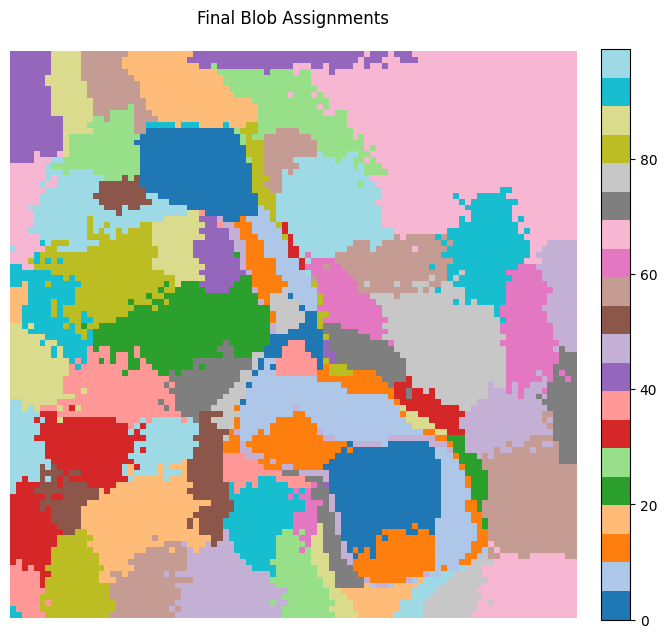

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
blob_assignments_img = converged_state.datapoints_state.blob_assignments.reshape((target_hw, target_hw))
im = ax.matshow(blob_assignments_img, cmap='tab20')
ax.set_title('Final Blob Assignments', pad=20)
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Per-Pixel Hyperblob Visualization with Analysis

/var/tmp/ipykernel_17787/3404172346.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hyperblob_colored = cm.get_cmap('tab10')((hyperblob_img + 1) / (number_of_hyperblobs + 1))


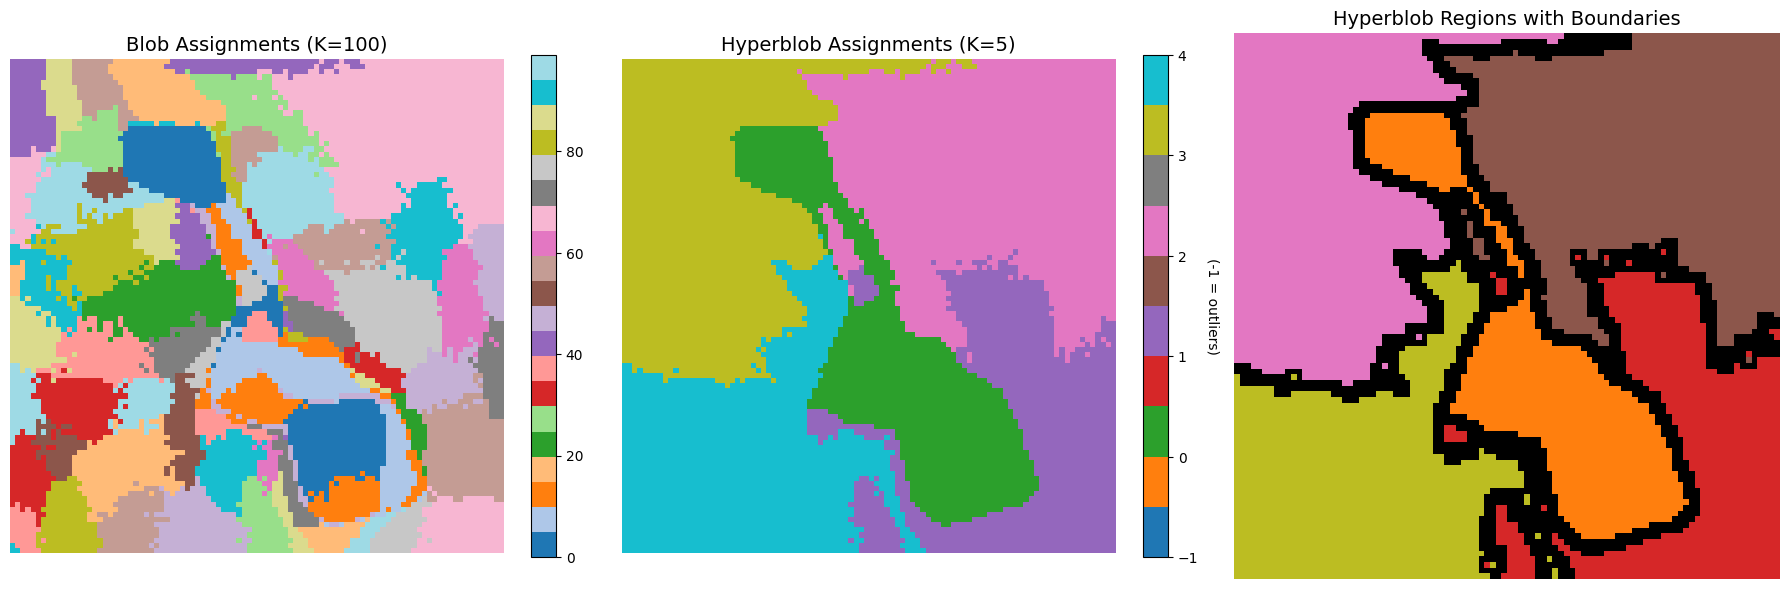


HIERARCHICAL SEGMENTATION STATISTICS

HYPERBLOB ANALYSIS:
----------------------------------------------------------------------
Hyperblob 0:
  - Pixels: 1403 (15.2%)
  - Blobs: 22
  - Points: 1403
  - Spatial extent (X,Y,Z): (1.774, 2.005, 1.418)
Hyperblob 1:
  - Pixels: 1475 (16.0%)
  - Blobs: 17
  - Points: 1475
  - Spatial extent (X,Y,Z): (1.853, 1.686, 0.877)
Hyperblob 2:
  - Pixels: 2484 (27.0%)
  - Blobs: 20
  - Points: 2484
  - Spatial extent (X,Y,Z): (1.928, 1.685, 0.711)
Hyperblob 3:
  - Pixels: 2067 (22.4%)
  - Blobs: 22
  - Points: 2067
  - Spatial extent (X,Y,Z): (2.363, 2.121, 0.932)
Hyperblob 4:
  - Pixels: 1787 (19.4%)
  - Blobs: 19
  - Points: 1787
  - Spatial extent (X,Y,Z): (1.927, 2.028, 0.836)

Outliers: 0 pixels (0.0%)

----------------------------------------------------------------------
BLOB-LEVEL STATISTICS:
----------------------------------------------------------------------
Active blobs: 87 / 100
Blob size - Mean: 105.9, Std: 116.8
Blob size - Min: 1, Max

In [15]:
# Extract assignments
blob_assignments = np.array(converged_state.datapoints_state.blob_assignments)
blob_to_hyperblob = np.array(converged_state.blobs_state.hyperblob_assignments)

# Map pixels -> blobs -> hyperblobs
pixel_hyperblobs = np.zeros_like(blob_assignments)
for i in range(len(blob_assignments)):
    blob_id = blob_assignments[i]
    if blob_id < number_of_blobs:
        pixel_hyperblobs[i] = blob_to_hyperblob[blob_id]
    else:
        pixel_hyperblobs[i] = -1  # Outliers

# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Blob assignments
blob_img = blob_assignments.reshape((target_hw, target_hw))
im1 = axes[0].imshow(blob_img, cmap='tab20')
axes[0].set_title(f'Blob Assignments (K={number_of_blobs})', fontsize=14)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046)

# Plot 2: Hyperblob assignments (via blob mapping)
hyperblob_img = pixel_hyperblobs.reshape((target_hw, target_hw))
im2 = axes[1].imshow(hyperblob_img, cmap='tab10', vmin=-1, vmax=number_of_hyperblobs-1)
axes[1].set_title(f'Hyperblob Assignments (K={number_of_hyperblobs})', fontsize=14)
axes[1].axis('off')
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046)
cbar2.set_label('(-1 = outliers)', rotation=270, labelpad=15)

# Plot 3: Hyperblob regions with boundaries
# Use Sobel edge detection to highlight boundaries
edges_x = sobel(hyperblob_img, axis=0)
edges_y = sobel(hyperblob_img, axis=1)
edges = np.hypot(edges_x, edges_y)
edges = edges > 0.5

# Create colored hyperblob image with black boundaries
hyperblob_colored = cm.get_cmap('tab10')((hyperblob_img + 1) / (number_of_hyperblobs + 1))
hyperblob_colored[edges] = [0, 0, 0, 1]  # Black boundaries

axes[2].imshow(hyperblob_colored)
axes[2].set_title('Hyperblob Regions with Boundaries', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*70)
print("HIERARCHICAL SEGMENTATION STATISTICS")
print("="*70)

print("\nHYPERBLOB ANALYSIS:")
print("-" * 70)
for hb_id in range(number_of_hyperblobs):
    # Pixels in this hyperblob
    hb_pixels = np.sum(pixel_hyperblobs == hb_id)
    
    # Blobs assigned to this hyperblob
    hb_blobs = np.where(blob_to_hyperblob == hb_id)[0]
    
    # Points assigned to blobs in this hyperblob
    hb_blob_mask = np.isin(blob_assignments, hb_blobs)
    hb_points = np.sum(hb_blob_mask)
    
    print(f"Hyperblob {hb_id}:")
    print(f"  - Pixels: {hb_pixels} ({100*hb_pixels/len(pixel_hyperblobs):.1f}%)")
    print(f"  - Blobs: {len(hb_blobs)}")
    print(f"  - Points: {hb_points}")
    
    if len(hb_blobs) > 0:
        # Compute spatial extent
        hb_positions = tracked_points_frame0[hb_blob_mask]
        if len(hb_positions) > 0:
            extent = np.ptp(hb_positions, axis=0)
            print(f"  - Spatial extent (X,Y,Z): ({extent[0]:.3f}, {extent[1]:.3f}, {extent[2]:.3f})")

# Outlier statistics
outlier_pixels = np.sum(pixel_hyperblobs == -1)
print(f"\nOutliers: {outlier_pixels} pixels ({100*outlier_pixels/len(pixel_hyperblobs):.1f}%)")

# Blob-level statistics
print("\n" + "-" * 70)
print("BLOB-LEVEL STATISTICS:")
print("-" * 70)

active_blobs = np.unique(blob_assignments[blob_assignments < number_of_blobs])
print(f"Active blobs: {len(active_blobs)} / {number_of_blobs}")

blob_sizes = [np.sum(blob_assignments == i) for i in active_blobs]
print(f"Blob size - Mean: {np.mean(blob_sizes):.1f}, Std: {np.std(blob_sizes):.1f}")
print(f"Blob size - Min: {np.min(blob_sizes)}, Max: {np.max(blob_sizes)}")

# Hyperblob weights
hyperblob_weights = np.array(converged_state.hyperblobs_state.hyperblob_weights)
print("\nHyperblob weights:")
for hb_id in range(number_of_hyperblobs):
    print(f"  Hyperblob {hb_id}: {hyperblob_weights[hb_id]:.4f}")

print("="*70)

## 3D Visualization of Final Hierarchical Structure

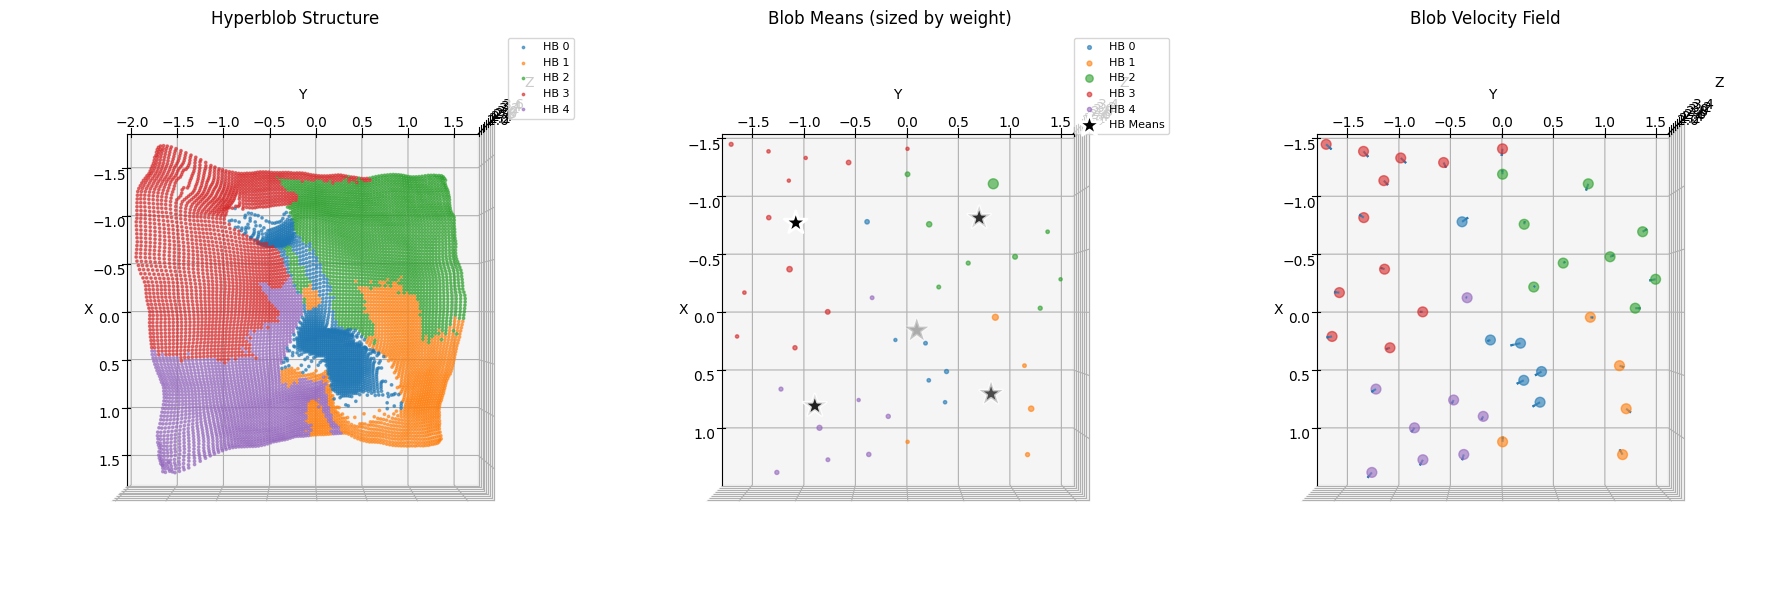

In [16]:
fig = plt.figure(figsize=(18, 6))

# Plot 1: All blobs colored by hyperblob
ax1 = fig.add_subplot(131, projection='3d')
for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(blob_to_hyperblob == hb_id)[0]
    hb_mask = np.isin(blob_assignments, hb_blobs) & (blob_assignments < number_of_blobs)
    if np.sum(hb_mask) > 0:
        pts = tracked_points_frame0[hb_mask]
        pts_vis = pts[:, [1, 0, 2]]  # Transpose for visualization
        ax1.scatter(pts_vis[:, 0], pts_vis[:, 1], pts_vis[:, 2], s=3, alpha=0.6, label=f'HB {hb_id}')

outlier_mask = blob_assignments >= number_of_blobs
if np.sum(outlier_mask) > 0:
    outlier_pts = tracked_points_frame0[outlier_mask]
    outlier_pts_vis = outlier_pts[:, [1, 0, 2]]  # Transpose for visualization
    ax1.scatter(outlier_pts_vis[:, 0], outlier_pts_vis[:, 1], outlier_pts_vis[:, 2],
               c='gray', s=1, alpha=0.2, label='Outliers')

ax1.set_title('Hyperblob Structure', fontsize=12)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.legend(loc='upper right', fontsize=8)
ax1.view_init(elev=90, azim=0)

# Plot 2: Blob means colored by hyperblob
ax2 = fig.add_subplot(132, projection='3d')
blob_means = np.array(converged_state.blobs_state.blob_means)
blob_weights = np.array(converged_state.blobs_state.blob_weights)

for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(blob_to_hyperblob == hb_id)[0]
    active_hb_blobs = hb_blobs[blob_weights[hb_blobs] > 0.01]
    if len(active_hb_blobs) > 0:
        means = blob_means[active_hb_blobs]
        means_vis = means[:, [1, 0, 2]]  # Transpose for visualization
        weights = blob_weights[active_hb_blobs]
        ax2.scatter(means_vis[:, 0], means_vis[:, 1], means_vis[:, 2],
                   s=weights*500, alpha=0.6, label=f'HB {hb_id}')

# Add hyperblob means
hyperblob_means = np.array(converged_state.hyperblobs_state.hyperblob_means)
hyperblob_means_vis = hyperblob_means[:, [1, 0, 2]]  # Transpose for visualization
ax2.scatter(hyperblob_means_vis[:, 0], hyperblob_means_vis[:, 1], hyperblob_means_vis[:, 2],
           c='black', marker='*', s=300, edgecolors='white', linewidths=2,
           label='HB Means', zorder=10)

ax2.set_title('Blob Means (sized by weight)', fontsize=12)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.legend(loc='upper right', fontsize=8)
ax2.view_init(elev=90, azim=0)

# Plot 3: Velocity field
ax3 = fig.add_subplot(133, projection='3d')
blob_vel_means = np.array(converged_state.blobs_state.blob_vel_means)

for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(blob_to_hyperblob == hb_id)[0]
    active_hb_blobs = hb_blobs[blob_weights[hb_blobs] > 0.01]
    if len(active_hb_blobs) > 0:
        means = blob_means[active_hb_blobs]
        means_vis = means[:, [1, 0, 2]]  # Transpose for visualization
        vels = blob_vel_means[active_hb_blobs]
        vels_vis = vels[:, [1, 0, 2]]  # Transpose for visualization

        # Plot points
        ax3.scatter(means_vis[:, 0], means_vis[:, 1], means_vis[:, 2], s=50, alpha=0.6)

        # Plot velocity vectors
        for i in range(len(means_vis)):
            ax3.quiver(means_vis[i, 0], means_vis[i, 1], means_vis[i, 2],
                      vels_vis[i, 0], vels_vis[i, 1], vels_vis[i, 2],
                      length=0.1, normalize=True, alpha=0.7)

ax3.set_title('Blob Velocity Field', fontsize=12)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.view_init(elev=90, azim=0)

plt.tight_layout()
plt.show()

## Max Scoring Trace Visualization

MAXIMUM SCORING TRACE
Maximum log probability: 107259.6172
Found at iteration: 80 (sample 8)
Final iteration log prob: 107178.7656

Rebuilding choice map for max scoring trace...
Verified log probability: 107259.6172
Trace successfully rebuilt!



/var/tmp/ipykernel_17787/710270924.py:191: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hyperblob_colored = cm.get_cmap('tab10')((hyperblob_img + 1) / (number_of_hyperblobs + 1))


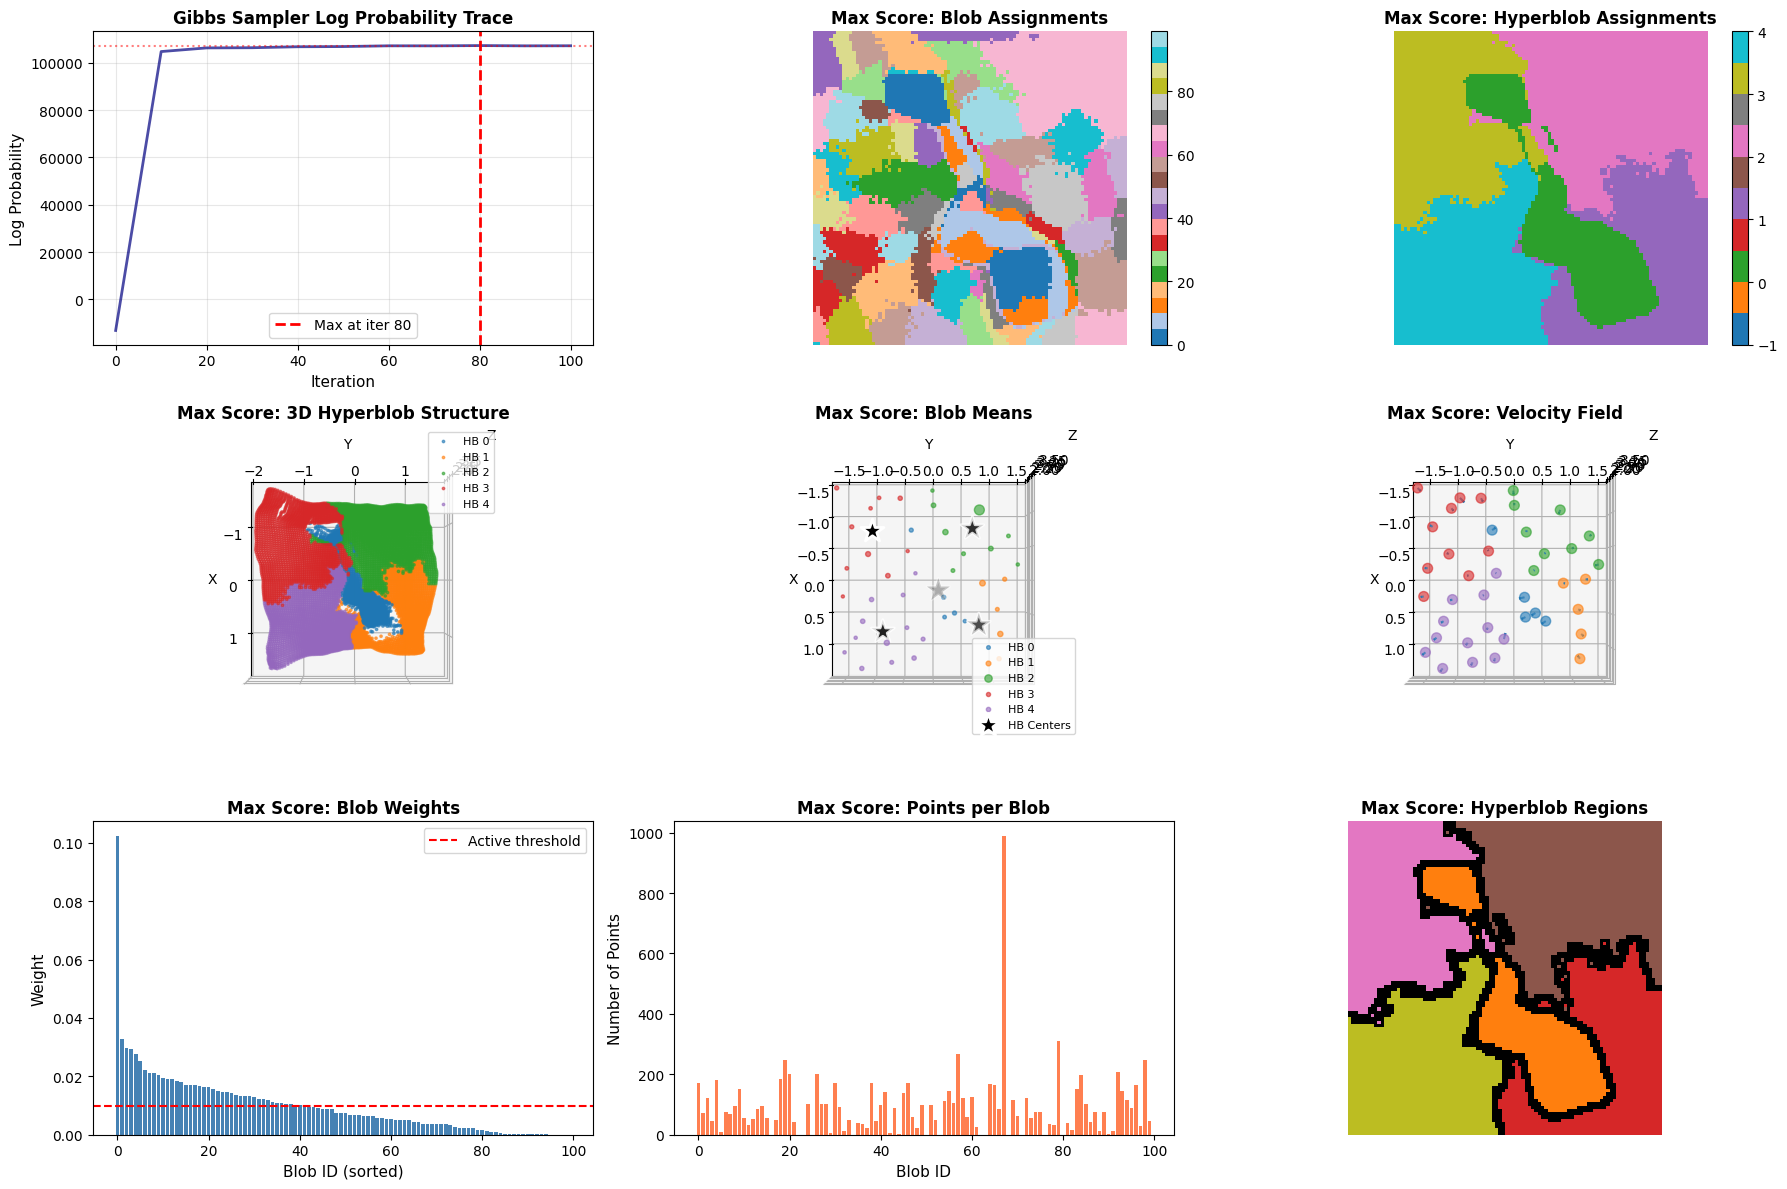


MAX SCORING TRACE STATISTICS
Log probability: 107259.6172
Iteration: 80 / 102

Outliers: 0 / 9216 (0.00%)
Active blobs: 41 / 100
Mean points per active blob: 224.8

Hyperblob distribution:
  Hyperblob 0: 1290 pixels (14.0%), 18 blobs
  Hyperblob 1: 1658 pixels (18.0%), 17 blobs
  Hyperblob 2: 2496 pixels (27.1%), 21 blobs
  Hyperblob 3: 1811 pixels (19.7%), 23 blobs
  Hyperblob 4: 1961 pixels (21.3%), 21 blobs

Hyperblob weights:
  Hyperblob 0: 0.1530
  Hyperblob 1: 0.1680
  Hyperblob 2: 0.2695
  Hyperblob 3: 0.1943
  Hyperblob 4: 0.2152

Max scoring trace is now available as 'max_score_trace' for further processing
Max scoring state is available as 'max_score_state'
Max scoring choice map is available as 'max_chm'


In [17]:
# Find the max scoring trace and rebuild it
from gestalt_experiment_algorithm import HDGMM_model_3d
from genjax import ChoiceMapBuilder as C

# Find max scoring sample
max_score_idx_in_sampled = np.argmax(log_probs)
max_score_idx = max_score_idx_in_sampled * sample_freq  # Convert to actual iteration index
max_score_state = gibbs_wtrs[max_score_idx].retval

print("="*70)
print("MAXIMUM SCORING TRACE")
print("="*70)
print(f"Maximum log probability: {log_probs[max_score_idx_in_sampled]:.4f}")
print(f"Found at iteration: {max_score_idx} (sample {max_score_idx_in_sampled})")
print(f"Final iteration log prob: {log_probs[-1]:.4f}")
print("="*70)

# Rebuild the choice map for the max scoring trace
print("\nRebuilding choice map for max scoring trace...")
max_chm = (
    C['hyperblobs', 'hyperblob_weights'].set(max_score_state.hyperblobs_state.hyperblob_weights) |
    C['hyperblobs', 'hyperblob_means'].set(max_score_state.hyperblobs_state.hyperblob_means) |
    C['hyperblobs', 'hyperblob_covs'].set(max_score_state.hyperblobs_state.hyperblob_covs) |
    C['hyperblobs', 'hyperblob_trans_vels'].set(max_score_state.hyperblobs_state.hyperblob_trans_vels) |
    C['hyperblobs', 'hyperblob_rot_vels'].set(max_score_state.hyperblobs_state.hyperblob_rot_vels) |
    
    C['blobs', 'hyperblob_assignments'].set(max_score_state.blobs_state.hyperblob_assignments) |
    C['blobs', 'blob_weights'].set(max_score_state.blobs_state.blob_weights) |
    C['blobs', 'blob_means'].set(max_score_state.blobs_state.blob_means) |
    C['blobs', 'blob_covs'].set(max_score_state.blobs_state.blob_covs) |
    C['blobs', 'blob_vel_means'].set(max_score_state.blobs_state.blob_vel_means) |
    C['blobs', 'blob_vel_covs'].set(max_score_state.blobs_state.blob_vel_covs) |
    
    C['datapoints', 'blob_assignments'].set(max_score_state.datapoints_state.blob_assignments) |
    C['datapoints', 'datapoint_positions'].set(max_score_state.datapoints_state.datapoint_positions) |
    C['datapoints', 'datapoint_vels'].set(max_score_state.datapoints_state.datapoint_vels)
)

# Assess to verify the score
verified_weight, max_score_trace = HDGMM_model_3d.assess(max_chm, (max_score_state.hypers,))
print(f"Verified log probability: {float(verified_weight):.4f}")
print("Trace successfully rebuilt!\n")

# Extract assignments for visualization
max_blob_assignments = np.array(max_score_state.datapoints_state.blob_assignments)
max_blob_weights = np.array(max_score_state.blobs_state.blob_weights)
max_hyperblob_assignments = np.array(max_score_state.blobs_state.hyperblob_assignments)

# Map pixels to hyperblobs
max_pixel_hyperblobs = np.zeros_like(max_blob_assignments)
for i in range(len(max_blob_assignments)):
    blob_id = max_blob_assignments[i]
    if blob_id < number_of_blobs:
        max_pixel_hyperblobs[i] = max_hyperblob_assignments[blob_id]
    else:
        max_pixel_hyperblobs[i] = -1

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))

# Log probability trace
ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(iterations, log_probs, linewidth=2, color='navy', alpha=0.7)
ax1.axvline(max_score_idx, color='red', linestyle='--', linewidth=2, label=f'Max at iter {max_score_idx}')
ax1.axhline(log_probs[max_score_idx_in_sampled], color='red', linestyle=':', alpha=0.5)
ax1.set_xlabel('Iteration', fontsize=11)
ax1.set_ylabel('Log Probability', fontsize=11)
ax1.set_title('Gibbs Sampler Log Probability Trace', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Blob assignments
ax2 = fig.add_subplot(3, 3, 2)
blob_img = max_blob_assignments.reshape((target_hw, target_hw))
im2 = ax2.imshow(blob_img, cmap='tab20')
ax2.set_title(f'Max Score: Blob Assignments', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046)

# Hyperblob assignments
ax3 = fig.add_subplot(3, 3, 3)
hyperblob_img = max_pixel_hyperblobs.reshape((target_hw, target_hw))
im3 = ax3.imshow(hyperblob_img, cmap='tab10', vmin=-1, vmax=number_of_hyperblobs-1)
ax3.set_title(f'Max Score: Hyperblob Assignments', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046)

# 3D scatter: All points colored by hyperblob
ax4 = fig.add_subplot(3, 3, 4, projection='3d')
for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(max_hyperblob_assignments == hb_id)[0]
    hb_mask = np.isin(max_blob_assignments, hb_blobs) & (max_blob_assignments < number_of_blobs)
    if np.sum(hb_mask) > 0:
        pts = tracked_points_frame0[hb_mask]
        pts_vis = pts[:, [1, 0, 2]]
        ax4.scatter(pts_vis[:, 0], pts_vis[:, 1], pts_vis[:, 2], s=3, alpha=0.6, label=f'HB {hb_id}')

outlier_mask = max_blob_assignments >= number_of_blobs
if np.sum(outlier_mask) > 0:
    outlier_pts = tracked_points_frame0[outlier_mask]
    outlier_pts_vis = outlier_pts[:, [1, 0, 2]]
    ax4.scatter(outlier_pts_vis[:, 0], outlier_pts_vis[:, 1], outlier_pts_vis[:, 2],
               c='gray', s=1, alpha=0.2, label='Outliers')

ax4.set_title('Max Score: 3D Hyperblob Structure', fontsize=12, fontweight='bold')
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
ax4.legend(fontsize=8)
ax4.view_init(elev=90, azim=0)

# Blob means sized by weight
ax5 = fig.add_subplot(3, 3, 5, projection='3d')
max_blob_means = np.array(max_score_state.blobs_state.blob_means)
max_hyperblob_means = np.array(max_score_state.hyperblobs_state.hyperblob_means)

for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(max_hyperblob_assignments == hb_id)[0]
    active_hb_blobs = hb_blobs[max_blob_weights[hb_blobs] > 0.01]
    if len(active_hb_blobs) > 0:
        means = max_blob_means[active_hb_blobs]
        means_vis = means[:, [1, 0, 2]]
        weights = max_blob_weights[active_hb_blobs]
        ax5.scatter(means_vis[:, 0], means_vis[:, 1], means_vis[:, 2],
                   s=weights*500, alpha=0.6, label=f'HB {hb_id}')

# Add hyperblob means
hyperblob_means_vis = max_hyperblob_means[:, [1, 0, 2]]
ax5.scatter(hyperblob_means_vis[:, 0], hyperblob_means_vis[:, 1], hyperblob_means_vis[:, 2],
           c='black', marker='*', s=300, edgecolors='white', linewidths=2,
           label='HB Centers', zorder=10)

ax5.set_title('Max Score: Blob Means', fontsize=12, fontweight='bold')
ax5.set_xlabel('X')
ax5.set_ylabel('Y')
ax5.set_zlabel('Z')
ax5.legend(fontsize=8)
ax5.view_init(elev=90, azim=0)

# Velocity field
ax6 = fig.add_subplot(3, 3, 6, projection='3d')
max_blob_vel_means = np.array(max_score_state.blobs_state.blob_vel_means)

for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(max_hyperblob_assignments == hb_id)[0]
    active_hb_blobs = hb_blobs[max_blob_weights[hb_blobs] > 0.01]
    if len(active_hb_blobs) > 0:
        means = max_blob_means[active_hb_blobs]
        means_vis = means[:, [1, 0, 2]]
        vels = max_blob_vel_means[active_hb_blobs]
        vels_vis = vels[:, [1, 0, 2]]
        
        ax6.scatter(means_vis[:, 0], means_vis[:, 1], means_vis[:, 2], s=50, alpha=0.6)
        
        for i in range(len(means_vis)):
            ax6.quiver(means_vis[i, 0], means_vis[i, 1], means_vis[i, 2],
                      vels_vis[i, 0], vels_vis[i, 1], vels_vis[i, 2],
                      length=0.1, normalize=True, alpha=0.7)

ax6.set_title('Max Score: Velocity Field', fontsize=12, fontweight='bold')
ax6.set_xlabel('X')
ax6.set_ylabel('Y')
ax6.set_zlabel('Z')
ax6.view_init(elev=90, azim=0)

# Blob weight distribution
ax7 = fig.add_subplot(3, 3, 7)
sorted_weights = np.sort(max_blob_weights)[::-1]
ax7.bar(range(len(sorted_weights)), sorted_weights, color='steelblue')
ax7.set_xlabel('Blob ID (sorted)', fontsize=11)
ax7.set_ylabel('Weight', fontsize=11)
ax7.set_title(f'Max Score: Blob Weights', fontsize=12, fontweight='bold')
ax7.axhline(0.01, color='red', linestyle='--', label='Active threshold')
ax7.legend()

# Blob assignments distribution
ax8 = fig.add_subplot(3, 3, 8)
unique_assignments, counts = np.unique(max_blob_assignments[max_blob_assignments < number_of_blobs], 
                                       return_counts=True)
ax8.bar(unique_assignments, counts, color='coral')
ax8.set_xlabel('Blob ID', fontsize=11)
ax8.set_ylabel('Number of Points', fontsize=11)
ax8.set_title('Max Score: Points per Blob', fontsize=12, fontweight='bold')

# Hyperblob with boundaries
ax9 = fig.add_subplot(3, 3, 9)
edges_x = sobel(hyperblob_img, axis=0)
edges_y = sobel(hyperblob_img, axis=1)
edges = np.hypot(edges_x, edges_y) > 0.5

hyperblob_colored = cm.get_cmap('tab10')((hyperblob_img + 1) / (number_of_hyperblobs + 1))
hyperblob_colored[edges] = [0, 0, 0, 1]

ax9.imshow(hyperblob_colored)
ax9.set_title('Max Score: Hyperblob Regions', fontsize=12, fontweight='bold')
ax9.axis('off')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*70)
print("MAX SCORING TRACE STATISTICS")
print("="*70)
print(f"Log probability: {log_probs[max_score_idx_in_sampled]:.4f}")
print(f"Iteration: {max_score_idx} / {len(gibbs_wtrs)}")

outlier_count = np.sum(max_blob_assignments >= number_of_blobs)
print(f"\nOutliers: {outlier_count} / {len(max_blob_assignments)} ({100*outlier_count/len(max_blob_assignments):.2f}%)")

active_blobs = np.sum(max_blob_weights > 0.01)
print(f"Active blobs: {active_blobs} / {number_of_blobs}")

if active_blobs > 0:
    inlier_count = np.sum(max_blob_assignments < number_of_blobs)
    print(f"Mean points per active blob: {inlier_count / active_blobs:.1f}")

print("\nHyperblob distribution:")
for hb_id in range(number_of_hyperblobs):
    hb_pixels = np.sum(max_pixel_hyperblobs == hb_id)
    hb_blobs = np.sum(max_hyperblob_assignments == hb_id)
    print(f"  Hyperblob {hb_id}: {hb_pixels} pixels ({100*hb_pixels/len(max_pixel_hyperblobs):.1f}%), {hb_blobs} blobs")

max_hyperblob_weights = np.array(max_score_state.hyperblobs_state.hyperblob_weights)
print("\nHyperblob weights:")
for hb_id in range(number_of_hyperblobs):
    print(f"  Hyperblob {hb_id}: {max_hyperblob_weights[hb_id]:.4f}")

print("="*70)
print("\nMax scoring trace is now available as 'max_score_trace' for further processing")
print("Max scoring state is available as 'max_score_state'")
print("Max scoring choice map is available as 'max_chm'")

Probe point sampled from ROI: (66, 77)


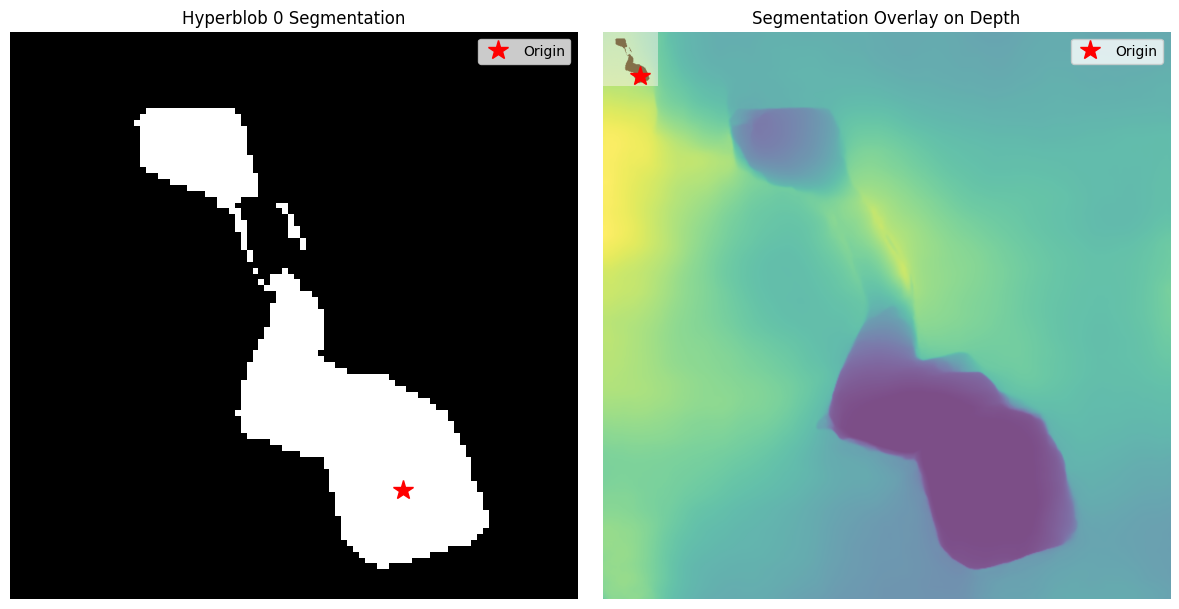

Saved segmentation to: one_frame_gestalt_masks/scene_00001_texture_00_origin_hyperblob_segmentation.png
Origin pixel (66, 77) belongs to Hyperblob 0
Segmentation contains 1290 pixels (14.0%)


In [18]:
# Save segmentation for hyperblobs at origin pixel as PNG
from PIL import Image
import os

# Create output directory
os.makedirs('one_frame_gestalt_masks', exist_ok=True)

# Robustly sample probe point from ROI mask instead of using center
roi_mask_indices = np.where(combined_mask)[0]
if len(roi_mask_indices) > 0:
    # Randomly sample a point from the ROI
    probe_pixel_idx = np.random.choice(roi_mask_indices)
    origin_pixel_idx = probe_pixel_idx
    origin_y, origin_x = probe_pixel_idx // target_hw, probe_pixel_idx % target_hw
    print(f"Probe point sampled from ROI: ({origin_x}, {origin_y})")
else:
    # Fallback to center if no ROI found
    origin_x, origin_y = target_hw // 2, target_hw // 2
    origin_pixel_idx = origin_y * target_hw + origin_x
    print(f"Warning: No ROI found, using center: ({origin_x}, {origin_y})")

# Find which blob the origin belongs to
origin_blob = max_blob_assignments[origin_pixel_idx]

if origin_blob < number_of_blobs:
    # Find which hyperblob this blob belongs to
    origin_hyperblob = max_hyperblob_assignments[origin_blob]
    
    # Get all pixels belonging to this hyperblob
    origin_hyperblob_mask = max_pixel_hyperblobs == origin_hyperblob
    
    # Create binary mask image (white = mask, black = background)
    mask_img = (origin_hyperblob_mask.reshape((target_hw, target_hw)) * 255).astype(np.uint8)
    
    # Save as PNG
    output_path = f'one_frame_gestalt_masks/{explore_scene}_{explore_texture}_origin_hyperblob_segmentation.png'
    Image.fromarray(mask_img).save(output_path)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(mask_img, cmap='gray')
    axes[0].plot(origin_x, origin_y, 'r*', markersize=15, label='Origin')
    axes[0].set_title(f'Hyperblob {origin_hyperblob} Segmentation')
    axes[0].legend()
    axes[0].axis('off')
    
    axes[1].imshow(depth[0], cmap='viridis', alpha=0.7)
    axes[1].imshow(mask_img, cmap='Reds', alpha=0.5)
    axes[1].plot(origin_x, origin_y, 'r*', markersize=15, label='Origin')
    axes[1].set_title('Segmentation Overlay on Depth')
    axes[1].legend()
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Saved segmentation to: {output_path}")
    print(f"Origin pixel ({origin_x}, {origin_y}) belongs to Hyperblob {origin_hyperblob}")
    print(f"Segmentation contains {np.sum(origin_hyperblob_mask)} pixels ({100*np.sum(origin_hyperblob_mask)/len(origin_hyperblob_mask):.1f}%)")
else:
    print(f"Origin pixel is an outlier (blob_id={origin_blob})")

In [19]:
# can we run the segmenter? 

In [20]:
# Number of frames to track
num_tracking_frames = 5 #10

# Tracking Gibbs parameters
num_tracking_gibbs_iterations = 100  # Match frame 0 quality
num_velocity_update_iterations = 20   # Initial velocity update

# Storage for all frame results
all_frame_states = []
all_frame_masks = []
all_frame_motion_info = []
all_frame_log_probs = []
all_roi_hyperblob_ids = []  # Track which hyperblob is ROI at each frame

print(f"Running frame-by-frame tracking for {num_tracking_frames} frames...")
print(f"Using {num_tracking_gibbs_iterations} Gibbs iterations per frame")
print(f"NOTE: Object can translate and rotate - all velocities enabled")
print("="*70)

# Use the converged state from the first frame as initial state
current_state = converged_state

print(f"\nInitializing tracking with converged state from first frame")
print(f"  Number of blobs: {number_of_blobs}")
print(f"  Number of hyperblobs: {number_of_hyperblobs}")

for frame_idx in range(num_tracking_frames):
    print(f"\n--- Processing Frame {frame_idx + 1}/{num_tracking_frames} ---")
    
    # Get frame data
    tracked_points_frame = points_3d[frame_idx]
    tracked_motion_frame = motion_3d[frame_idx]
    
    # Extract motion information from current state
    blob_means_current = np.array(current_state.blobs_state.blob_means)
    blob_hyperblob_assignments = np.array(current_state.blobs_state.hyperblob_assignments)
    blob_vel_means_current = np.array(current_state.blobs_state.blob_vel_means)
    
    hyperblob_means_current = np.array(current_state.hyperblobs_state.hyperblob_means)
    hyperblob_trans_vels_current = np.array(current_state.hyperblobs_state.hyperblob_trans_vels)
    hyperblob_rot_vels_current = np.array(current_state.hyperblobs_state.hyperblob_rot_vels)
    
    # Print inferred motion from previous frame
    print(f"\n  Inferred Hyperblob Motion from Previous Frame:")
    print(f"  ------------------------------------------------")
    for hb_id in range(number_of_hyperblobs):
        hb_rot_vel = hyperblob_rot_vels_current[hb_id]
        # Extract rotation angle and axis from rotation matrix
        trace_R = np.trace(hb_rot_vel)
        cos_theta = np.clip((trace_R - 1) / 2, -1, 1)
        angle_rad = np.arccos(cos_theta)
        angle_deg = np.degrees(angle_rad)
        
        if angle_rad > 1e-6:
            sin_theta = np.sin(angle_rad)
            skew = (hb_rot_vel - hb_rot_vel.T) / 2
            axis = np.array([skew[2,1], skew[0,2], skew[1,0]]) / sin_theta
            axis_norm = np.linalg.norm(axis)
            axis = axis / axis_norm if axis_norm > 1e-6 else np.array([0., 0., 1.])
        else:
            axis = np.array([0., 0., 1.])
        
        print(f"    Hyperblob {hb_id}:")
        print(f"      Rotation: {angle_deg:.2f}° around axis [{axis[0]:+.3f}, {axis[1]:+.3f}, {axis[2]:+.3f}]")
    
    # Get blob-level motion statistics
    active_blob_mask = np.array(current_state.blobs_state.blob_weights) > 0.01
    active_blob_vels = blob_vel_means_current[active_blob_mask]
    if len(active_blob_vels) > 0:
        mean_blob_vel = np.mean(np.linalg.norm(active_blob_vels, axis=1))
        max_blob_vel = np.max(np.linalg.norm(active_blob_vels, axis=1))
        print(f"\n    Blob-level velocities:")
        print(f"      Mean magnitude: {mean_blob_vel:.4f}")
        print(f"      Max magnitude: {max_blob_vel:.4f}")
    
    # Store motion info from previous frame
    motion_info = {
        'hyperblob_trans_vels': hyperblob_trans_vels_current.copy(),
        'hyperblob_rot_vels': hyperblob_rot_vels_current.copy(),
        'blob_vel_means': blob_vel_means_current.copy(),
        'blob_means': blob_means_current.copy(),
        'hyperblob_means': hyperblob_means_current.copy()
    }
    all_frame_motion_info.append(motion_info)
    
    # Propagate blob positions using hyperblob ROTATION ONLY (no translation)
    propagated_blob_means = np.zeros_like(blob_means_current)
    
    print(f"\n  Propagating blob positions using hyperblob rotations (in-place):")
    for hb_id in range(number_of_hyperblobs):
        # Get blobs belonging to this hyperblob
        hb_blob_mask = blob_hyperblob_assignments == hb_id
        n_blobs_in_hb = np.sum(hb_blob_mask)
        
        if n_blobs_in_hb > 0:
            # Get hyperblob center (stays fixed)
            hb_center = hyperblob_means_current[hb_id]
            
              # Get rotation and translation velocities
            hb_rotation = hyperblob_rot_vels_current[hb_id]
            
            # For each blob in this hyperblob
            for blob_id in np.where(hb_blob_mask)[0]:
                # Get blob position relative to hyperblob center
                blob_pos = blob_means_current[blob_id]
                relative_pos = blob_pos - hb_center
                
                # Apply rotation only (R * relative_pos)
                rotated_relative_pos = hb_rotation @ relative_pos
                
                # Add back hyperblob center (no translation)
                propagated_blob_means[blob_id] = hb_center + rotated_relative_pos
            
            # Compute displacement statistics for this hyperblob
            displacements = np.linalg.norm(
                propagated_blob_means[hb_blob_mask] - blob_means_current[hb_blob_mask], 
                axis=1
            )
            mean_displacement = np.mean(displacements)
            print(f"    Hyperblob {hb_id}: {n_blobs_in_hb} blobs, mean displacement = {mean_displacement:.4f}")
    
    # Hyperblob means stay fixed (no translation)
    propagated_hyperblob_means = hyperblob_means_current.copy()
    
    # Get current blob and datapoint assignments
    current_blob_assignments = np.array(current_state.datapoints_state.blob_assignments)
    
    # Create choice map for this frame using propagated state
    from genjax import ChoiceMapBuilder as C
    
    propagated_chm = (
        C['hyperblobs', 'hyperblob_weights'].set(current_state.hyperblobs_state.hyperblob_weights) |
        C['hyperblobs', 'hyperblob_means'].set(propagated_hyperblob_means) |
        C['hyperblobs', 'hyperblob_covs'].set(current_state.hyperblobs_state.hyperblob_covs) |
        C['hyperblobs', 'hyperblob_trans_vels'].set(hyperblob_trans_vels_current) |
        C['hyperblobs', 'hyperblob_rot_vels'].set(hyperblob_rot_vels_current) |
        
        C['blobs', 'hyperblob_assignments'].set(blob_hyperblob_assignments) |
        C['blobs', 'blob_weights'].set(current_state.blobs_state.blob_weights) |
        C['blobs', 'blob_means'].set(propagated_blob_means) |
        C['blobs', 'blob_covs'].set(current_state.blobs_state.blob_covs) |
        C['blobs', 'blob_vel_means'].set(blob_vel_means_current) |
        C['blobs', 'blob_vel_covs'].set(current_state.blobs_state.blob_vel_covs) |
        
        C['datapoints', 'blob_assignments'].set(current_blob_assignments) |
        C['datapoints', 'datapoint_positions'].set(tracked_points_frame) |
        C['datapoints', 'datapoint_vels'].set(tracked_motion_frame)
    )
    
    # Initialize model with propagated state
    key, frame_key_importance = jax.random.split(key)
    frame_init_tr, _ = model_jimportance(frame_key_importance, propagated_chm, (current_state.hypers,))
    frame_init_hdgmm_state = frame_init_tr.get_retval()
    
    # STEP 1: Update velocities first (blob velocities and hyperblob rotations only)
    print(f"\n  Step 1: Updating velocities ({num_velocity_update_iterations} iterations)...")
    
    VELOCITY_UPDATE_DIALS = {
        "blob_weights": False,
        "hyperblob_weights": False,
        "blob_assignments": False,
        "hyperblob_assignments": False,
        "hyperblob_covs": False,
        "blob_covs": False,
        "blob_vel_covs": True,         # Update blob velocity covariances
        "blob_vel_means": True,         # Update blob velocity means
        "hyperblob_means": False,
        "blob_means": False,
        'hyperblob_rot_vels': True,     # Update hyperblob rotation velocities
        'hyperblob_trans_vels': True   # Enable translation - object can move
    }
    
    key, velocity_gibbs_key = jax.random.split(key)
    velocity_update_wtrs = hdgmm_full_gibbs(
        velocity_gibbs_key, 
        frame_init_hdgmm_state, 
        num_velocity_update_iterations,
        VELOCITY_UPDATE_DIALS, 
        use_weighted_blobs=True, 
        num_gibbs_inner_loops=num_inner_loops
    )
    
    # Pick best sample from velocity updates
    print(f"  Finding best velocity update sample...")
    velocity_log_probs = []
    velocity_sample_freq = max(1, num_velocity_update_iterations // 10)
    
    for idx in range(0, len(velocity_update_wtrs), velocity_sample_freq):
        state = velocity_update_wtrs[idx].retval
        chm = (
            C['hyperblobs', 'hyperblob_weights'].set(state.hyperblobs_state.hyperblob_weights) |
            C['hyperblobs', 'hyperblob_means'].set(state.hyperblobs_state.hyperblob_means) |
            C['hyperblobs', 'hyperblob_covs'].set(state.hyperblobs_state.hyperblob_covs) |
            C['hyperblobs', 'hyperblob_trans_vels'].set(state.hyperblobs_state.hyperblob_trans_vels) |
            C['hyperblobs', 'hyperblob_rot_vels'].set(state.hyperblobs_state.hyperblob_rot_vels) |
            C['blobs', 'hyperblob_assignments'].set(state.blobs_state.hyperblob_assignments) |
            C['blobs', 'blob_weights'].set(state.blobs_state.blob_weights) |
            C['blobs', 'blob_means'].set(state.blobs_state.blob_means) |
            C['blobs', 'blob_covs'].set(state.blobs_state.blob_covs) |
            C['blobs', 'blob_vel_means'].set(state.blobs_state.blob_vel_means) |
            C['blobs', 'blob_vel_covs'].set(state.blobs_state.blob_vel_covs) |
            C['datapoints', 'blob_assignments'].set(state.datapoints_state.blob_assignments) |
            C['datapoints', 'datapoint_positions'].set(state.datapoints_state.datapoint_positions) |
            C['datapoints', 'datapoint_vels'].set(state.datapoints_state.datapoint_vels)
        )
        weight, _ = HDGMM_model_3d.assess(chm, (state.hypers,))
        velocity_log_probs.append(float(weight))
    
    best_velocity_idx = np.argmax(velocity_log_probs) * velocity_sample_freq
    velocity_updated_state = velocity_update_wtrs[best_velocity_idx].retval
    print(f"  Best sample at iteration {best_velocity_idx}, log prob: {velocity_log_probs[np.argmax(velocity_log_probs)]:.2f}")
    
    # Print updated velocities with proper rotation angle/axis
    updated_hyperblob_rot_vels = np.array(velocity_updated_state.hyperblobs_state.hyperblob_rot_vels)
    
    print(f"\n  Updated Hyperblob Motion (Rotation Only):")
    for hb_id in range(number_of_hyperblobs):
        hb_rot_vel = updated_hyperblob_rot_vels[hb_id]
        trace_R = np.trace(hb_rot_vel)
        cos_theta = np.clip((trace_R - 1) / 2, -1, 1)
        angle_rad = np.arccos(cos_theta)
        angle_deg = np.degrees(angle_rad)
        
        if angle_rad > 1e-6:
            sin_theta = np.sin(angle_rad)
            skew = (hb_rot_vel - hb_rot_vel.T) / 2
            axis = np.array([skew[2,1], skew[0,2], skew[1,0]]) / sin_theta
            axis_norm = np.linalg.norm(axis)
            axis = axis / axis_norm if axis_norm > 1e-6 else np.array([0., 0., 1.])
        else:
            axis = np.array([0., 0., 1.])
        
        print(f"    Hyperblob {hb_id}: {angle_deg:.2f}° around [{axis[0]:+.3f}, {axis[1]:+.3f}, {axis[2]:+.3f}]")
    
    # STEP 2: Full Gibbs sampling
    print(f"\n  Step 2: Full Gibbs sampling ({num_tracking_gibbs_iterations} iterations)...")
    
    key, frame_gibbs_key = jax.random.split(key)
    frame_gibbs_wtrs = hdgmm_full_gibbs(
        frame_gibbs_key, 
        velocity_updated_state,
        num_tracking_gibbs_iterations, 
        GIBBS_DIALS, 
        use_weighted_blobs=True, 
        num_gibbs_inner_loops=num_inner_loops
    )
    
    # Pick best sample from full Gibbs
    print(f"  Finding best full Gibbs sample...")
    full_log_probs = []
    full_sample_freq = max(1, num_tracking_gibbs_iterations // 20)
    
    for idx in range(0, len(frame_gibbs_wtrs), full_sample_freq):
        state = frame_gibbs_wtrs[idx].retval
        chm = (
            C['hyperblobs', 'hyperblob_weights'].set(state.hyperblobs_state.hyperblob_weights) |
            C['hyperblobs', 'hyperblob_means'].set(state.hyperblobs_state.hyperblob_means) |
            C['hyperblobs', 'hyperblob_covs'].set(state.hyperblobs_state.hyperblob_covs) |
            C['hyperblobs', 'hyperblob_trans_vels'].set(state.hyperblobs_state.hyperblob_trans_vels) |
            C['hyperblobs', 'hyperblob_rot_vels'].set(state.hyperblobs_state.hyperblob_rot_vels) |
            C['blobs', 'hyperblob_assignments'].set(state.blobs_state.hyperblob_assignments) |
            C['blobs', 'blob_weights'].set(state.blobs_state.blob_weights) |
            C['blobs', 'blob_means'].set(state.blobs_state.blob_means) |
            C['blobs', 'blob_covs'].set(state.blobs_state.blob_covs) |
            C['blobs', 'blob_vel_means'].set(state.blobs_state.blob_vel_means) |
            C['blobs', 'blob_vel_covs'].set(state.blobs_state.blob_vel_covs) |
            C['datapoints', 'blob_assignments'].set(state.datapoints_state.blob_assignments) |
            C['datapoints', 'datapoint_positions'].set(state.datapoints_state.datapoint_positions) |
            C['datapoints', 'datapoint_vels'].set(state.datapoints_state.datapoint_vels)
        )
        weight, _ = HDGMM_model_3d.assess(chm, (state.hypers,))
        full_log_probs.append(float(weight))
    
    best_full_idx = np.argmax(full_log_probs) * full_sample_freq
    current_state = frame_gibbs_wtrs[best_full_idx].retval
    best_log_prob = full_log_probs[np.argmax(full_log_probs)]
    
    print(f"  Best sample at iteration {best_full_idx}, log prob: {best_log_prob:.2f}")
    all_frame_log_probs.append(best_log_prob)
    
    # Extract blob and hyperblob assignments
    frame_blob_assignments = np.array(current_state.datapoints_state.blob_assignments)
    frame_hyperblob_assignments = np.array(current_state.blobs_state.hyperblob_assignments)
    
    # Map pixels to hyperblobs
    frame_pixel_hyperblobs = np.zeros_like(frame_blob_assignments)
    for i in range(len(frame_blob_assignments)):
        blob_id = frame_blob_assignments[i]
        if blob_id < number_of_blobs:
            frame_pixel_hyperblobs[i] = frame_hyperblob_assignments[blob_id]
        else:
            frame_pixel_hyperblobs[i] = -1
    
    # Determine ROI hyperblob for this frame
    # Get current frame segmentation mask
    frame_segmentation_mask = all_frame_segmentation_masks[frame_idx]
    
    # Count how many pixels from each hyperblob overlap with the ROI mask
    hyperblob_roi_overlap = np.zeros(number_of_hyperblobs)
    for hb_id in range(number_of_hyperblobs):
        hb_mask = (frame_pixel_hyperblobs == hb_id)
        overlap = np.sum(hb_mask & frame_segmentation_mask)
        hyperblob_roi_overlap[hb_id] = overlap
    
    # The ROI hyperblob is the one with maximum overlap
    frame_roi_hyperblob_id = int(np.argmax(hyperblob_roi_overlap)) if np.sum(hyperblob_roi_overlap) > 0 else 0
    print(f"  ROI hyperblob ID: {frame_roi_hyperblob_id} (overlap: {int(hyperblob_roi_overlap[frame_roi_hyperblob_id])} pixels)")
    
    # Store results
    all_frame_states.append(current_state)
    all_roi_hyperblob_ids.append(frame_roi_hyperblob_id)
    all_frame_masks.append(frame_pixel_hyperblobs)
    
    n_outliers = np.sum(frame_blob_assignments >= number_of_blobs)
    n_active_blobs = np.sum(np.array(current_state.blobs_state.blob_weights) > 0.01)
    print(f"  ✓ Complete!")
    print(f"    Outliers: {n_outliers}/{len(frame_blob_assignments)} ({100*n_outliers/len(frame_blob_assignments):.1f}%)")
    print(f"    Active blobs: {n_active_blobs}/{number_of_blobs}")

print("\n" + "="*70)
print(f"✓ All {num_tracking_frames} frames processed successfully!")
print(f"Mean log probability across frames: {np.mean(all_frame_log_probs):.2f}")
print("="*70)

Running frame-by-frame tracking for 5 frames...
Using 100 Gibbs iterations per frame
NOTE: Object can translate and rotate - all velocities enabled

Initializing tracking with converged state from first frame
  Number of blobs: 100
  Number of hyperblobs: 5

--- Processing Frame 1/5 ---

  Inferred Hyperblob Motion from Previous Frame:
  ------------------------------------------------
    Hyperblob 0:
      Rotation: 5.00° around axis [+0.478, +0.878, +0.000]
    Hyperblob 1:
      Rotation: 10.00° around axis [-0.890, +0.456, +0.000]
    Hyperblob 2:
      Rotation: 5.00° around axis [+0.100, +0.995, +0.000]
    Hyperblob 3:
      Rotation: 1.50° around axis [-0.997, -0.083, +0.000]
    Hyperblob 4:
      Rotation: 6.00° around axis [+0.789, +0.614, +0.000]

    Blob-level velocities:
      Mean magnitude: 0.1615
      Max magnitude: 1.3800

  Propagating blob positions using hyperblob rotations (in-place):
    Hyperblob 0: 22 blobs, mean displacement = 0.0399
    Hyperblob 1: 17 blo

## Visualize Inferred Motion Over Time

Plot the inferred translation and rotation velocities for each hyperblob across all frames.

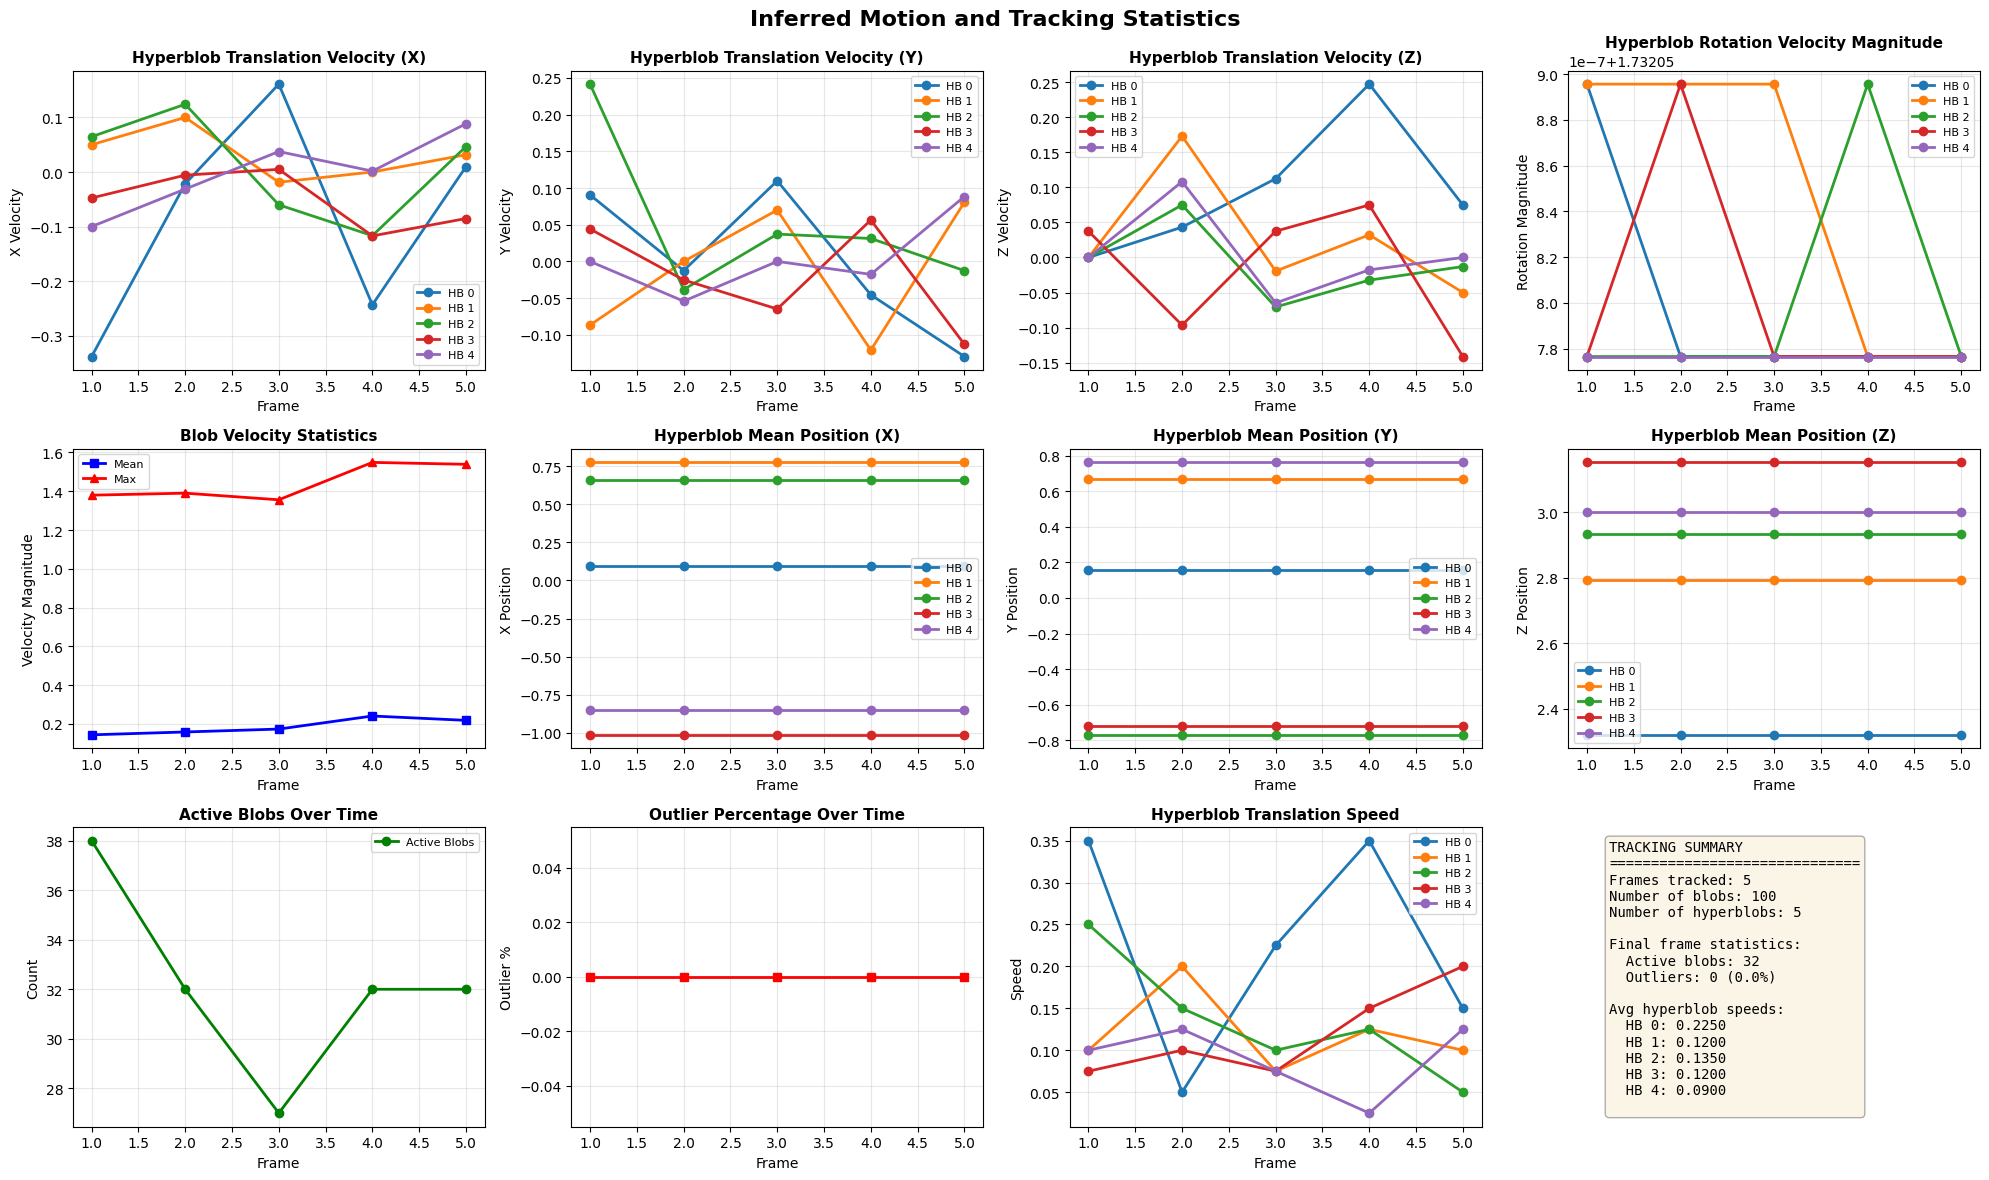


✓ Motion visualization complete


In [21]:
# Extract motion data for all frames
frames = np.arange(1, num_tracking_frames + 1)

# Create comprehensive motion visualization
fig = plt.figure(figsize=(20, 12))

# Plot hyperblob translation velocities (X, Y, Z components)
for component_idx, component_name in enumerate(['X', 'Y', 'Z']):
    ax = plt.subplot(3, 4, component_idx + 1)
    for hb_id in range(number_of_hyperblobs):
        trans_vels = [motion_info['hyperblob_trans_vels'][hb_id][component_idx] 
                      for motion_info in all_frame_motion_info]
        ax.plot(frames, trans_vels, marker='o', linewidth=2, label=f'HB {hb_id}')
    ax.set_xlabel('Frame', fontsize=10)
    ax.set_ylabel(f'{component_name} Velocity', fontsize=10)
    ax.set_title(f'Hyperblob Translation Velocity ({component_name})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Plot hyperblob rotation velocity magnitudes
ax = plt.subplot(3, 4, 4)
for hb_id in range(number_of_hyperblobs):
    rot_vel_mags = [np.linalg.norm(motion_info['hyperblob_rot_vels'][hb_id]) 
                    for motion_info in all_frame_motion_info]
    ax.plot(frames, rot_vel_mags, marker='o', linewidth=2, label=f'HB {hb_id}')
ax.set_xlabel('Frame', fontsize=10)
ax.set_ylabel('Rotation Magnitude', fontsize=10)
ax.set_title('Hyperblob Rotation Velocity Magnitude', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot blob velocity statistics
ax = plt.subplot(3, 4, 5)
mean_blob_vels = []
max_blob_vels = []
for motion_info in all_frame_motion_info:
    blob_vels = motion_info['blob_vel_means']
    vel_mags = np.linalg.norm(blob_vels, axis=1)
    mean_blob_vels.append(np.mean(vel_mags))
    max_blob_vels.append(np.max(vel_mags))

ax.plot(frames, mean_blob_vels, marker='s', linewidth=2, label='Mean', color='blue')
ax.plot(frames, max_blob_vels, marker='^', linewidth=2, label='Max', color='red')
ax.set_xlabel('Frame', fontsize=10)
ax.set_ylabel('Velocity Magnitude', fontsize=10)
ax.set_title('Blob Velocity Statistics', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot hyperblob mean positions over time (to show trajectory)
for component_idx, component_name in enumerate(['X', 'Y', 'Z']):
    ax = plt.subplot(3, 4, 6 + component_idx)
    for hb_id in range(number_of_hyperblobs):
        hb_positions = []
        for state in all_frame_states:
            hb_mean = np.array(state.hyperblobs_state.hyperblob_means)[hb_id]
            hb_positions.append(hb_mean[component_idx])
        ax.plot(frames, hb_positions, marker='o', linewidth=2, label=f'HB {hb_id}')
    ax.set_xlabel('Frame', fontsize=10)
    ax.set_ylabel(f'{component_name} Position', fontsize=10)
    ax.set_title(f'Hyperblob Mean Position ({component_name})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Plot number of active blobs and outliers over time
ax = plt.subplot(3, 4, 9)
n_active_blobs = []
n_outliers = []
n_total_points = []

for state in all_frame_states:
    blob_weights = np.array(state.blobs_state.blob_weights)
    blob_assignments = np.array(state.datapoints_state.blob_assignments)
    
    n_active_blobs.append(np.sum(blob_weights > 0.01))
    n_outliers.append(np.sum(blob_assignments >= number_of_blobs))
    n_total_points.append(len(blob_assignments))

ax.plot(frames, n_active_blobs, marker='o', linewidth=2, label='Active Blobs', color='green')
ax.set_xlabel('Frame', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_title('Active Blobs Over Time', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = plt.subplot(3, 4, 10)
outlier_pct = [100 * n_outliers[i] / n_total_points[i] for i in range(len(n_outliers))]
ax.plot(frames, outlier_pct, marker='s', linewidth=2, color='red')
ax.set_xlabel('Frame', fontsize=10)
ax.set_ylabel('Outlier %', fontsize=10)
ax.set_title('Outlier Percentage Over Time', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot hyperblob velocity magnitudes (combined translation)
ax = plt.subplot(3, 4, 11)
for hb_id in range(number_of_hyperblobs):
    trans_vel_mags = [np.linalg.norm(motion_info['hyperblob_trans_vels'][hb_id]) 
                      for motion_info in all_frame_motion_info]
    ax.plot(frames, trans_vel_mags, marker='o', linewidth=2, label=f'HB {hb_id}')
ax.set_xlabel('Frame', fontsize=10)
ax.set_ylabel('Speed', fontsize=10)
ax.set_title('Hyperblob Translation Speed', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Summary statistics text
ax = plt.subplot(3, 4, 12)
ax.axis('off')
summary_text = f"TRACKING SUMMARY\n{'='*30}\n"
summary_text += f"Frames tracked: {num_tracking_frames}\n"
summary_text += f"Number of blobs: {number_of_blobs}\n"
summary_text += f"Number of hyperblobs: {number_of_hyperblobs}\n\n"
summary_text += f"Final frame statistics:\n"
summary_text += f"  Active blobs: {n_active_blobs[-1]}\n"
summary_text += f"  Outliers: {n_outliers[-1]} ({outlier_pct[-1]:.1f}%)\n\n"

# Compute average velocities
avg_trans_vels = np.mean([np.linalg.norm(motion_info['hyperblob_trans_vels'], axis=1) 
                          for motion_info in all_frame_motion_info], axis=0)
summary_text += f"Avg hyperblob speeds:\n"
for hb_id in range(number_of_hyperblobs):
    summary_text += f"  HB {hb_id}: {avg_trans_vels[hb_id]:.4f}\n"

ax.text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center',
        family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Inferred Motion and Tracking Statistics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Motion visualization complete")

## Save Tracked Segmentation Masks

Save the segmentation masks for all tracked frames to a new folder.

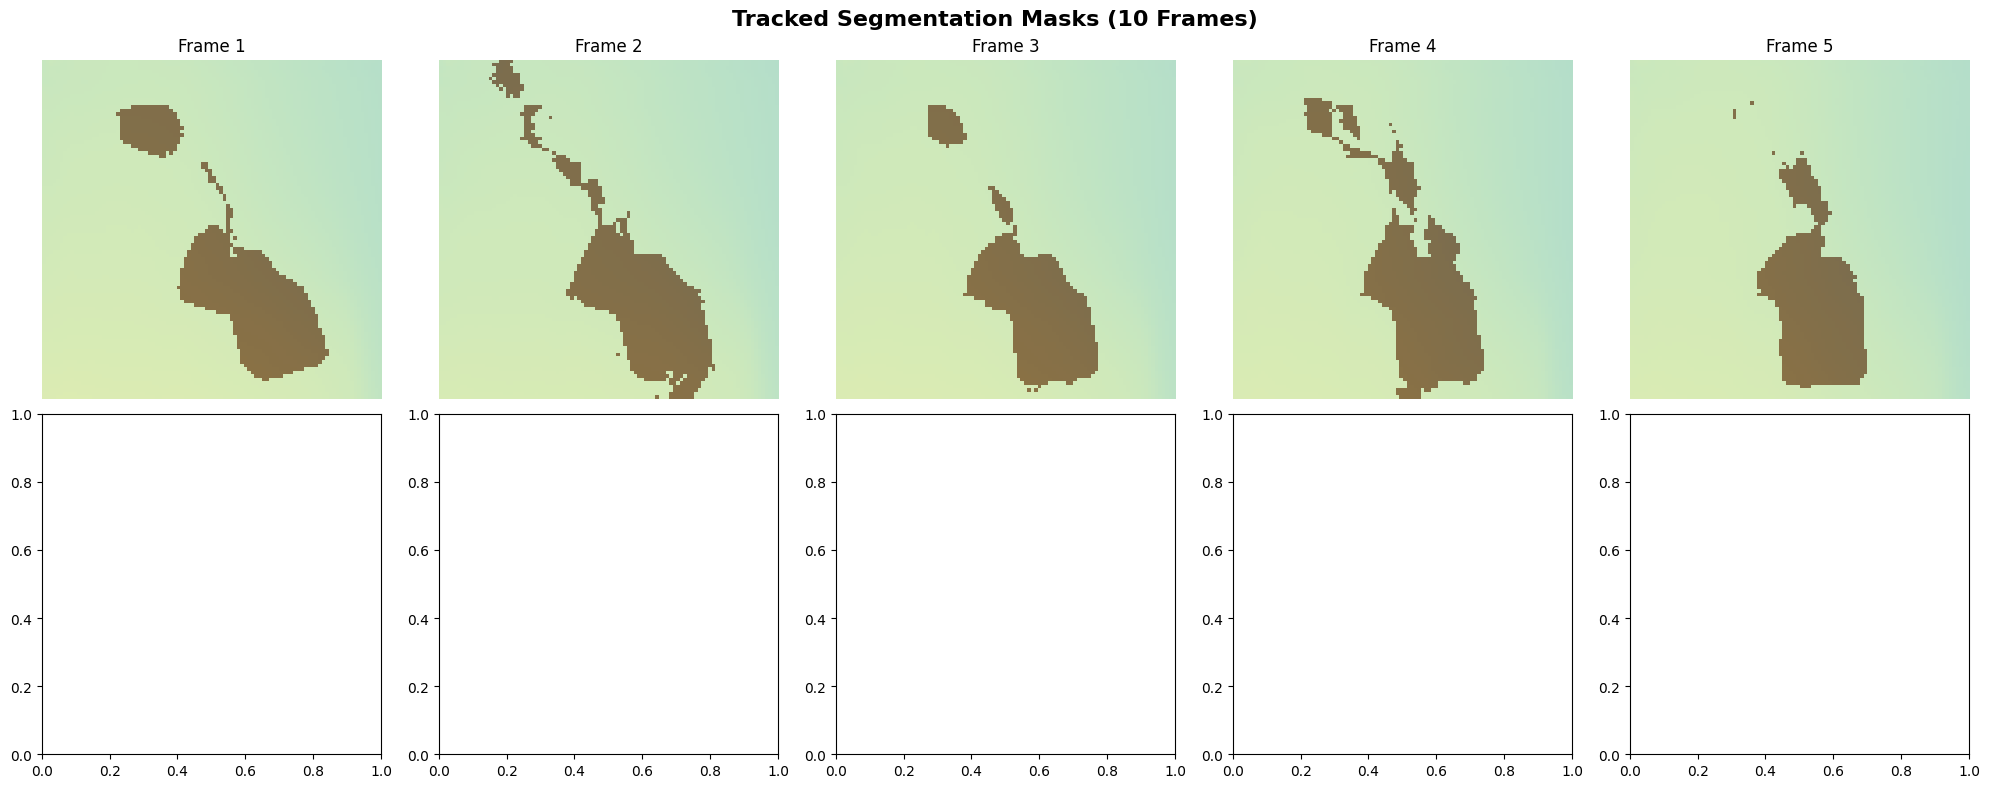


✓ Visualized all 5 tracked frames


In [22]:
# Visualize all tracked frames in a grid
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for frame_idx in range(num_tracking_frames):
    # Get frame state
    frame_state = all_frame_states[frame_idx]
    
    # Get blob and hyperblob assignments
    frame_blob_assignments = np.array(frame_state.datapoints_state.blob_assignments)
    frame_hyperblob_assignments = np.array(frame_state.blobs_state.hyperblob_assignments)
    
    # Map datapoints to hyperblobs
    frame_pixel_hyperblobs = np.array([
        frame_hyperblob_assignments[blob_id] if blob_id < len(frame_hyperblob_assignments) else -1
        for blob_id in frame_blob_assignments
    ])
    
    # Use the ROI hyperblob ID determined by mask-guided k-means
    roi_hyperblob_id = all_roi_hyperblob_ids[frame_idx]
    roi_hyperblob_mask = (frame_pixel_hyperblobs == roi_hyperblob_id)
    
    # Create binary mask image
    mask_img = (roi_hyperblob_mask.reshape((target_hw, target_hw)) * 255).astype(np.uint8)
    
    # Display
    axes[frame_idx].imshow(depth[frame_idx], cmap='viridis', alpha=0.7)
    axes[frame_idx].imshow(mask_img, cmap='Reds', alpha=0.5)
    axes[frame_idx].set_title(f'Frame {frame_idx + 1}', fontsize=12)
    axes[frame_idx].axis('off')

plt.suptitle('Tracked Segmentation Masks (10 Frames)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✓ Visualized all {num_tracking_frames} tracked frames")

## Accuracy Evaluation

Compute segmentation accuracy by sampling probe points from the true mask.

**Method:**
1. For each frame, sample multiple probe points from the TRUE ROI mask
2. For each probe point:
   - Find which estimated hyperblob contains that point
   - Compute pixel-wise accuracy of that hyperblob's mask vs true mask (over whole image)
3. Average the accuracy scores across all probe points and all frames

This gives us the expected accuracy when using any point from the true ROI as a probe.

ACCURACY EVALUATION
Frame 1: Accuracy = 0.908 ± 0.123 (n=100 probes)
Frame 2: Accuracy = 0.873 ± 0.124 (n=100 probes)
Frame 3: Accuracy = 0.887 ± 0.139 (n=100 probes)
Frame 4: Accuracy = 0.870 ± 0.123 (n=100 probes)
Frame 5: Accuracy = 0.877 ± 0.141 (n=100 probes)

OVERALL ACCURACY: 0.883 ± 0.014
  Averaged over 5 frames
  100 probe points sampled per frame


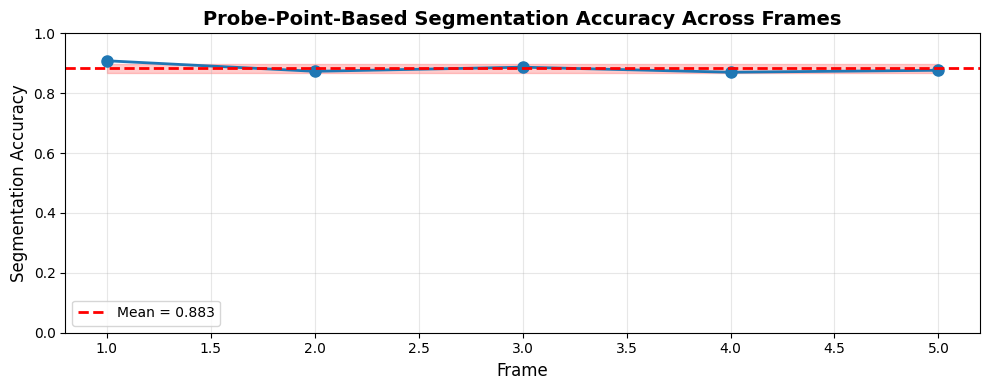


✓ Accuracy evaluation complete!


In [23]:
# Accuracy Evaluation with Probe Point Sampling

def compute_segmentation_accuracy(true_mask, estimated_mask):
    """
    Compute pixel-wise accuracy between true and estimated masks.
    
    Args:
        true_mask: Boolean array (H*W,) - ground truth
        estimated_mask: Boolean array (H*W,) - predicted segmentation
    
    Returns:
        accuracy: Float in [0, 1]
    """
    # Pixel-wise accuracy over entire image
    correct = (true_mask == estimated_mask)
    accuracy = np.mean(correct)
    return accuracy

def evaluate_frame_with_probe_sampling(frame_idx, num_probes=50):
    """
    Evaluate segmentation accuracy for a frame by sampling probe points from true mask.
    
    Args:
        frame_idx: Frame index to evaluate
        num_probes: Number of probe points to sample from true mask
    
    Returns:
        mean_accuracy: Average accuracy across all probe points
        std_accuracy: Standard deviation of accuracies
        probe_accuracies: List of individual probe accuracies
    """
    # Get true mask and estimated state for this frame
    true_mask = all_frame_segmentation_masks[frame_idx]
    frame_state = all_frame_states[frame_idx]
    
    # Get estimated blob and hyperblob assignments
    frame_blob_assignments = np.array(frame_state.datapoints_state.blob_assignments)
    frame_hyperblob_assignments = np.array(frame_state.blobs_state.hyperblob_assignments)
    
    # Map datapoints to hyperblobs
    frame_pixel_hyperblobs = np.array([
        frame_hyperblob_assignments[blob_id] if blob_id < len(frame_hyperblob_assignments) else -1
        for blob_id in frame_blob_assignments
    ])
    
    # Find probe points (indices where true mask is True)
    true_roi_indices = np.where(true_mask)[0]
    
    if len(true_roi_indices) == 0:
        print(f"Warning: Frame {frame_idx} has no true ROI points")
        return 0.0, 0.0, []
    
    # Sample probe points (with replacement if fewer than num_probes)
    num_samples = min(num_probes, len(true_roi_indices))
    probe_indices = np.random.choice(true_roi_indices, size=num_samples, replace=False)
    
    probe_accuracies = []
    
    for probe_idx in probe_indices:
        # Find which hyperblob contains this probe point
        probe_hyperblob_id = frame_pixel_hyperblobs[probe_idx]
        
        if probe_hyperblob_id < 0:
            # Probe point is an outlier - skip
            continue
        
        # Create estimated mask for this hyperblob
        estimated_mask = (frame_pixel_hyperblobs == probe_hyperblob_id)
        
        # Compute accuracy
        accuracy = compute_segmentation_accuracy(true_mask, estimated_mask)
        probe_accuracies.append(accuracy)
    
    if len(probe_accuracies) == 0:
        return 0.0, 0.0, []
    
    mean_accuracy = np.mean(probe_accuracies)
    std_accuracy = np.std(probe_accuracies)
    
    return mean_accuracy, std_accuracy, probe_accuracies

# Run evaluation across all tracked frames
print("="*60)
print("ACCURACY EVALUATION")
print("="*60)

num_probes_per_frame = 100
all_frame_accuracies = []

for frame_idx in range(num_tracking_frames):
    mean_acc, std_acc, probe_accs = evaluate_frame_with_probe_sampling(
        frame_idx, 
        num_probes=num_probes_per_frame
    )
    
    all_frame_accuracies.append(mean_acc)
    
    print(f"Frame {frame_idx+1}: Accuracy = {mean_acc:.3f} ± {std_acc:.3f} (n={len(probe_accs)} probes)")

# Overall statistics
overall_mean = np.mean(all_frame_accuracies)
overall_std = np.std(all_frame_accuracies)

print("\n" + "="*60)
print(f"OVERALL ACCURACY: {overall_mean:.3f} ± {overall_std:.3f}")
print(f"  Averaged over {num_tracking_frames} frames")
print(f"  {num_probes_per_frame} probe points sampled per frame")
print("="*60)

# Visualize accuracy across frames
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(range(1, num_tracking_frames+1), all_frame_accuracies, 'o-', linewidth=2, markersize=8)
ax.axhline(overall_mean, color='red', linestyle='--', linewidth=2, label=f'Mean = {overall_mean:.3f}')
ax.fill_between(range(1, num_tracking_frames+1), 
                 overall_mean - overall_std, 
                 overall_mean + overall_std, 
                 alpha=0.2, color='red')
ax.set_xlabel('Frame', fontsize=12)
ax.set_ylabel('Segmentation Accuracy', fontsize=12)
ax.set_title('Probe-Point-Based Segmentation Accuracy Across Frames', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n✓ Accuracy evaluation complete!")